In [1]:
# Eigenmode
import gmsh
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve import Mesh, HCurl, H1, specialcf
from ngsolve import BilinearForm, SymbolicBFI, grad, curl
from ngsolve.la import EigenValues_Preconditioner
import scipy.sparse as sp

settings = {'Objects': {'Clipping Plane': True, 'Vectors': True}, 'Colormap': {'ncolors': 125},
            'Clipping': {'enable': True, 'x': 1, 'y': 0, 'z': 0},
           'Vectors': {'grid_size': 200}}

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

def eig_analytic(gfu, n_z=0):
    # rect waveguide dimensions
    L, b = 1000e-3, 100e-3
    a = 2*b
    
    # Analytic field
    k_nz = n_z * np.pi / L
    A0 = (2/(a*b))**0.5
    E_y = A0 * (np.pi / a) * sin(np.pi * x / a) * cos(k_nz * z)
    gfu.Set((0, E_y, 0))
    gfu = BoundaryFromVolumeCF(gfu)
    
    return Norm(gfu)

def rwg():
    L, b = 1000e-3, 100e-3
    a = 2*b
    rwg = Rectangle(a, b).Face().Extrude(L*Z)
    # rwg = Box((0, 0, 0), (a, b, L))
    rwg.faces.Min(X).name = "PEC"
    rwg.faces.Max(X).name = "PEC"
    rwg.faces.Min(Y).name = "PEC"
    rwg.faces.Max(Y).name = "PEC"
    rwg.faces.Min(Z).name = "PMC"
    rwg.faces.Max(Z).name = "PMC"

    rwg.mat('vacuum')

    mesh = Mesh(OCCGeometry(rwg).GenerateMesh(maxh=0.1))
    mesh.Curve(3)
    # Draw(mesh)
    return mesh


def solve():
    with TaskManager():
        a.Assemble()
        m.Assemble()
        acsr = -sp.csr_matrix(a.mat.CSR())
        mcsr = sp.csr_matrix(m.mat.CSR())
        freedofs = fes.FreeDofs()
        print(acsr.shape, mcsr.shape, np.max(acsr), np.max(mcsr))
        evals, evecs = sp.linalg.eigs(acsr[freedofs, :][:, freedofs], k=20, M=mcsr[freedofs, :][:, freedofs], sigma=240)
        print(np.sort(np.abs(evals)))

        apre.Assemble()

        G, fesh1 = fes.CreateGradient()
        GT = G.CreateTranspose()
        math1 = GT @ m.mat @ G
    #     math1[0, 0] += 1
        invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fesh1.FreeDofs())

        proj = IdentityMatrix() - G@invh1@GT@m.mat
        projpre = proj @ pre.mat

        evals, evecs = solvers.PINVIT(a.mat, m.mat, pre=projpre, num=10, maxit=20,
                                      printrates=False)
    print('pinvit', evals)
    freq_fes = []
    for i, lam in enumerate(evals):
        freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
#     print(freq_fes)

    # plot results
    gfu_E = []
    gfu_H = []
    for i in range(len(evecs)):
        w = 2 * pi * freq_fes[i] * 1e6
        gfu = GridFunction(fes)
        gfu.vec.data = evecs[i]

        gfu_E.append(gfu)
        gfu_H.append(1j / (mu0 * w) * curl(gfu))

    gfu_E = BoundaryFromVolumeCF(Norm(gfu_E[0]))
    # normalise by energy to 1J
    Un = Integrate(InnerProduct(gfu_E, gfu_E), mesh)
    gfu_E = gfu_E/np.sqrt(Un)
    
    # get analytic solution
    gfu_analytic = eig_analytic(GridFunction(fes))
    # normalise by energy to 1J
    Ua = Integrate(InnerProduct(gfu_analytic, gfu_analytic), mesh)
    gfu_analytic = gfu_analytic/np.sqrt(Ua)
    
    error = gfu_analytic - gfu_E[0]
    
    return fes.ndof, error, gfu_analytic, Norm(gfu_E[0])

Draw(BoundaryFromVolumeCF(Norm(gfu_E[1])), mesh, order=4, settings=settings)
# Draw(gfu_E[1], mesh, settings=settings)

NameError: name 'gfu_E' is not defined

In [ ]:
# hp convergence
maxerr = []
orders = [3]
maxerrs = {}
ndofs = {}

for ord in orders:
    ndof = 0
    print(ord)
    # get mesh
    mesh = rwg()
    maxerrs[ord] = []
    ndofs[ord] = []
    
    # setup fes
    order = ord
    fes = HCurl(mesh, order=order, dirichlet="PEC")
    u, v = fes.TnT()

    a = BilinearForm(curl(u)*curl(v)*dx)
    m = BilinearForm(u*v*dx)
    apre = BilinearForm(curl(u)*curl(v)*dx + u*v*dx)
    pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

    while ndof < 1e3:
        ndof, error, gfua, gfun = solve()
        ndofs[ord].append(ndof)
        
        eta2 = Integrate(error, mesh, VOL, element_wise=True)
        maxerr = max(eta2)
        maxerrs[ord].append(maxerr)

        # mark elements for refinement
        mesh.ngmesh.Elements3D().NumPy()["refine"] = eta2.NumPy() > 0.25*maxerr
        mesh.Refine()
        print('end')

In [ ]:
import matplotlib.pyplot as plt
for ord, maxerr in maxerrs.items():
    plt.plot(ndofs[ord], maxerr, label=f'{ord}', marker='o', mec='k')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Degrees of freedom', fontsize=12)
plt.ylabel(r'$\max|E^{(e)}-E_{analytical}^{(e)}|$', fontsize=12)
plt.legend(title='Element order', fontsize=12)
plt.savefig('hp_adaptiv.png', dpi=300)
plt.show()

In [ ]:
import json
res = {'ndofs': ndofs, 'maxerrs': maxerrs}
with open('hp_adaptiv.json', 'w') as fp:
    json.dump(res, fp, sort_keys=True, indent=4)

In [ ]:
# # h convergence
# maxerr = []
# maxhs = np.linspace(0.05, 0.02, 10)
# orders = [1, 2, 3, 4]
# maxerrs = {}
# ndofs = {}
# for ord in orders:
#     maxerrs[ord] = []
#     ndofs[ord] = []
#     for maxh in maxhs:
#         print(maxh)
#         ndof, error, gfua, gfun, mesh = run_eigenmode(maxh, ord)
#     #     Draw(error, mesh, settings=settings)
#         eta2 = Integrate(error, mesh, VOL, element_wise=True)
#         maxerrs[ord].append(max(eta2))
#         ndofs[ord].append(ndof)
Draw(mesh)

In [ ]:
# 2d Eigenmode
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw

settings = {'Objects': {'Clipping Plane': True, 'Vectors': True}, 'Colormap': {'ncolors': 125},
            'Clipping': {'enable': True, 'x': 1, 'y': 0, 'z': 0},
           'Vectors': {'grid_size': 200}}

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

L, b = 1000e-3, 100e-3
a = 2*b
rwg = Rectangle(a, b).Face()

rwg.edges.Min(X).name = "PEC"
rwg.edges.Max(X).name = "PEC"
rwg.edges.Min(Y).name = "PEC"
rwg.edges.Max(Y).name = "PEC"
rwg.mat('vacuum')

mesh = Mesh(OCCGeometry(rwg, dim=2).GenerateMesh(maxh=0.03))
mesh.Curve(3)

# setup fes
order = 3
fes = HCurl(mesh, order=order, complex=True, dirichlet="PEC")
u, v = fes.TnT()

a = BilinearForm(curl(u)*curl(v)*dx)
m = BilinearForm(u*v*dx)

with TaskManager():
    a.Assemble()
    m.Assemble()
    
    E = GridFunction(fes, multidim=15, name='resonances')
    evals = ArnoldiSolver(a.mat, m.mat, fes.FreeDofs(),
                        list(E.vecs), shift=400)

freq_fes = []
for i, lam in enumerate(evals):
    freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
print(freq_fes)

Draw(Norm(E.MDComponent(0)), mesh)

In [ ]:
# help(G)

In [ ]:

# Draw (Norm(gfu.MDComponent(4)), mesh, order=4);

In [ ]:
from cavsim2d.solvers.NGSolve.eigen_ngsolve import suppress_c_stdout_stderr
from dataclasses import dataclass
#
import os
import gmsh
from ngsolve import  ( x, y, z, ds, dx, pi, Mesh, sin, cos, tan, exp, sqrt, BND, ArnoldiSolver,
    GridFunction, BilinearForm, LinearForm, InnerProduct, Cross, curl, BoundaryFromVolumeCF, ContactBoundary, BaseVector,
    Integrate, TaskManager, HCurl, Compress, Preconditioner, solvers, Norm, specialcf, ConvertOperator
)
from ngsolve.webgui import Draw
from netgen.occ import X, Y, Z, Rectangle, OCCGeometry, Axis
import scipy.sparse as sp

import matplotlib.pyplot as plt
%matplotlib widget

import numpy as np
import scipy.sparse as sp
from sksparse.cholmod import cholesky, CholmodError
from scipy.sparse.linalg import splu
from matplotlib.colors import Normalize
import matplotlib

def spy(A, cmap='tab20', markersize=10):
    """Visualise a sparse matrix (including complex) with colours representing entry magnitude."""
    A = A.tocoo()
    fig, ax = plt.subplots(figsize=(6,6))

    values = np.abs(A.data)  # take magnitudes for complex matrices
    norm = Normalize(vmin=values.min(), vmax=values.max())
    cmap_ = matplotlib.colormaps[cmap]

    sc = ax.scatter(A.col, A.row, marker='s', c=values, s=markersize,
                    cmap=cmap_, norm=norm)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Coloured sparse matrix pattern (|value|)")
    ax.set_xlabel("Column index")
    ax.set_ylabel("Row index")

    fig.colorbar(sc, ax=ax, label="|Value| magnitude")
    plt.show()

def test_and_factorize_sparse(M, name, test='Positive', tol=1e-12):
    """
    Performs symmetry and PD/PSD tests, accepts positive definite and positive semi-definite.
    Only fails if the matrix is not symmetric or has negative eigenvalues.
    """
    print(f"--- Testing Matrix {name} ---")

    if not (M - M.T).nnz == 0:
        diff = (M - M.conj().T).data
        max_diff = np.max(np.abs(diff)) if diff.size else 0
        if max_diff > tol:
            print(f"\x1b[31m SYMMETRY: Matrix is NOT symmetric (max diff {max_diff:.2e})\x1b[0m")
            return None, M, False
        else:
            print("\x1b[32m SYMMETRY: Matrix is symmetric.\x1b[0m")

    else:
        print("\x1b[32m SYMMETRY: Matrix is symmetric.\x1b[0m")

    M_csc = M.tocsc()

    try:
        factor = cholesky(M_csc)
        L = factor.L()
        P = factor.P()
        print(f"\x1b[32m Matrix is {test} Definite (PD). Cholesky succeeded.\n")
        R = L.T[P.argsort()][:, P.argsort()]
        return R, M, True

    except CholmodError as e:
        print("\t\x1b[33m Cholesky failed. Possibly semi-definite or singular.\x1b[0m")
        print("\tTrying regularised decomposition...")

        # Regularisation: shift matrix slightly by tol*I
        n = M.shape[0]
        M_reg = M_csc + sp.eye(n, format="csc") * tol
        try:
            factor = cholesky(M_reg)
            L = factor.L()
            P = factor.P()
            print(f"\t\x1b[32m Matrix is {test} Semi-Definite (PSD). Regularised Cholesky succeeded.\x1b[0m")
            R = L.T[P.argsort()][:, P.argsort()]
            return R, M_reg, True
        except CholmodError:
            print(f"\t\x1b[31m Matrix is NOT {test} Semi-Definite.\n\x1b[0m")
            return None, M, False

def check_singularity(K, tol=1e-12):
    """Safely test if sparse matrix K is singular or nearly singular."""
    K_csc = K.tocsc()
    try:
        lu = splu(K_csc)
        diagU = lu.U.diagonal()
        det = np.prod(diagU)
        if abs(det) < tol:
            print("Matrix is singular or nearly singular.")
        else:
            print("Matrix is non-singular.")
        print("Determinant (approx):", det)
        return det
    except RuntimeError as e:
        print("LU factorisation failed (matrix may be singular).")
        print("Error:", e)
        return 0.0

def calc_error(R, M, name):
    M_reconstructed = R.transpose() @ R
    diff = M.toarray() - M_reconstructed.toarray()
    max_err = np.max(np.abs(diff))
    rel_max_err = max_err / np.max(np.abs(M.toarray()))

    print(f"\n--- Verification for {name} ---")
    print(f"Max reconstruction error: {max_err:.2e}")
    print("Relative max error:", rel_max_err)
    print()

def run_tests(A, name):
    R, A, res = test_and_factorize_sparse(A, name, test='Positive') # in case A is regularised
    if not res:
        print('_'*80)
        print("Cholesky failed. Possibly negative-definite, negative semi-definite or singular.")
        print('_'*80)
        R, A, res = test_and_factorize_sparse(-A, name, test='Negative') # in case A is regularised

    if R is not None:
        calc_error(R, A, name)

    check_singularity(A)
#     spy(A)
    print('='*80)
    return R

settings = {'Objects': {'Clipping Plane': True, 'Vectors': True},
            'Colormap': {'ncolors': 125},
            'Clipping': {'enable': True, 'x': 1, 'y': 0, 'z': 0},
            'Vectors': {'grid_size': 200},
            'Complex': {'animate': True}}

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

class RWG:
    def __init__(self, a, L, maxh=0.05):
        self.L = L
        self.a = a
        self.b = a/2
        self.geo = Rectangle(self.a, self.b).Face().Extrude(L*Z)
        self.geo.faces.Min(Z).name = "port1"
        self.geo.faces.Max(Z).name = "port2"
        self.geo.faces.Min(Y).name = "bottom"
        self.geo.faces.Max(Y).name = "top"
        self.geo.faces.Min(X).name = "left"
        self.geo.faces.Max(X).name = "right"
        self.geo.faces.Min(Z).col = (1, 0, 0)
        self.geo.faces.Max(Z).col = (1, 0, 0)
        self.geo.mat('vacuum')

        self.mesh = Mesh(OCCGeometry(self.geo).GenerateMesh(maxh=maxh))
        self.mesh.Curve(3)

class RWGAnalytic:
    def __init__(self, geo):
        self.Z11, self.Z21 = [], []
        self.geo = geo
        self.mesh = geo.mesh

    def analytic_field(self, freq):
        fes_analytic = HCurl(self.mesh, order=order, complex=True, dirichlet="top|bottom|left|right")

        # rect waveguide dimensions
        a, b, L = self.geo.a, self.geo.b, self.geo.L

        w = 2*pi*float(freq) # have to explicitly cast from numpy object to float
        Z0 = (mu0/eps0)**0.5
        kc = (pi/a)
        s = 1j*w
        wc = kc*c0
        ZTE = s*Z0/((s**2 + wc**2)**0.5)
        kz = w*mu0/ZTE

        # Analytic field
        A0 = (2/(a*b))**0.5
        print('A0=', A0)
        I1, I2 = 0.0, 1.0
        Vp = (1/2) * ZTE * (1 - 1/tan(kz * L)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2
        Vn = (ZTE / (exp(1j * 2 * kz * L) - 1)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2

        E_y = A0 * sin(np.pi * x / a) * (Vp*exp(-1j*kz*z) + Vn*exp(1j*kz*z))
        fes_analytic.Set((0, E_y, 0))
        gfu = BoundaryFromVolumeCF(fes_analytic)

        return gfu

    def analytic_(self, geo, pts):
        xi, yi, zi = pts[:,0], pts[:,1], pts[:,2]
        # rect waveguide dimensions
        a, b, L = geo.a, geo.b, geo.L

        w = 2*pi*float(freq) # have to explicitly cast from numpy object to float
        k = w/c0
        eta = (mu0/eps0)**0.5
        Z0 = eta
        kc = (pi/a)
        s = 1j*w
        wc = kc*c0
        ZTE = s*eta/((s**2 + wc**2)**0.5)
        kz = w*mu0/ZTE

        # Analytic field
        A0 = (2/(a*b))**0.5
        I1, I2 = 0.0, 1.0
        Vp = (1/2) * ZTE * (1 - 1/tan(kz * L)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2
        Vn = (ZTE / (exp(1j * 2 * kz * L) - 1)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2

        E_y = A0 * sin(np.pi * xi / a) * (Vp*exp(-1j*kz*zi) + Vn*exp(1j*kz*zi))
        return E_y

    def solve_FD(self, fmin, fmax, nsamples=1000):
        self.freqs = np.linspace(fmin, fmax, nsamples)*1e9
        for kk, freq in enumerate(self.freqs):
            a, b, L = self.geo.a, self.geo.b, self.geo.L
            w = 2*pi*freq
            k = w/c0
            Z0 = (mu0/eps0)**0.5
            kc = (pi/a)
            s = 1j*w
            wc = kc*c0
            ZTE = s*Z0/((s**2 + wc**2)**0.5)
            ZTEs.append(ZTE)
            kz = w*mu0/ZTE

            self.Z11.append(-1j*ZTE/np.tan(kz*L))
            self.Z21.append(-1j*ZTE/np.sin(kz*L))

class Structure:
    def __init__(self, geo):
        self.geo = geo
        self.mesh = geo.mesh

    def excitation_matrix_from_ports(self):
        # Get ports in order of appearance
        ports = [b for b in self.mesh.GetBoundaries() if "port" in b]
        n_ports = len(ports)

        # Identity matrix for excitation
        I = np.eye(n_ports, dtype=int)

        # Map port names to row indices
        port_indices = {port: i for i, port in enumerate(ports)}

        return I, ports, port_indices

    def get_rom(self):
        pass

    def fix_eigenmode(self, gfu, mesh, port, fesreal):
        # --- Step 1: Fix Phase (make it purely real) ---
        arr = gfu.vec.FV().NumPy()
        ref_idx = np.argmax(np.abs(arr))
        phase = np.angle(arr[ref_idx])
        gfu.vec.data = gfu.vec * np.exp(-1j * phase)
        # normalise ee to L such that int efield.efield dx = 1
        U = Integrate(InnerProduct(gfu, gfu), mesh, BND, definedon=mesh.Boundaries(port))
        gfu.vec.data = gfu.vec/np.sqrt(U)

        arr = gfu.vec.FV().NumPy()
        gfureal = GridFunction(fesreal)
        gfureal.vec.data = BaseVector(arr.real)
        return gfureal

    def parametric_line(self, start, end, npts=100000):
        t = np.linspace(0, 1, npts)
        line_points = start[None, :] + t[:, None] * (end - start)[None, :]
        return line_points

    def port_excitations(self, space, mesh, order, bc):
        # eigenmode on faces marked as ports
        Einc, nports = {}, 0
        mb = []
        for boundary_label in mesh.GetBoundaries():
            if 'port' in boundary_label:
                mb.append(mesh.Boundaries(boundary_label))
                nports += 1
                fes_port = Compress(space(mesh, order=order,
                                  dirichlet=bc, complex=True,
                                  definedon=mesh.Boundaries(boundary_label)))
                fesreal = Compress(space(mesh, order=order,
                                  dirichlet=bc,
                                  definedon=mesh.Boundaries(boundary_label)))
                Einc[boundary_label] = port_eigenmodes(fes_port, mesh, boundary_label, 1, fesreal)
    #             Einc[boundary_label] = port_eigenmodes(fes_port, boundary_label, 1, fes)

        return Einc, nports

    def port_eigenmodes(self, fes, mesh, port, nmodes=1, fesreal=None):
        u, v = fes.TnT()
        a = BilinearForm(curl(u.Trace())*curl(v.Trace())*ds(port))
        m = BilinearForm(u.Trace()*v.Trace()*ds(port))
        with TaskManager():
            a.Assemble()
            m.Assemble()

            E = GridFunction(fes, multidim=nmodes+2, name='resonances')
            evals = ArnoldiSolver(a.mat, m.mat, fes.FreeDofs(),
                                  list(E.vecs), shift=1) # TAKE NOTE OF THIS SHIFT WHEN CHANGING DIMENSIONS # MAKE ROBUST

        # sort and filter
        sort_idx = np.argsort(evals)
        evals = np.array(evals)[sort_idx]
        Evecs = np.array(E.vecs)[sort_idx]

        # remove eigenvalues < 1
        mask = evals > 1
        Evecs = Evecs[mask]
        evals = evals[mask]

        freq_fes = []
        for i, lam in enumerate(evals):
            freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
        # print(freq_fes)

        E = dict()
        for mode_num in range(nmodes):
            efield = GridFunction(fes)
            efield.vec.data = Evecs[mode_num]

            # rotate eigenmode to real line
            efield = fix_eigenmode(efield, mesh, port, fesreal)
            E[mode_num] = efield

        return E

    def check_port_normalisation(self, Einc):
        # confirm normalisation
        for port, efields in Einc.items():
            for mode, efield in efields.items():
                int_LmLm = Integrate(InnerProduct(efield, efield), mesh, BND, definedon=mesh.Boundaries(port))
                print('Confirm normalisation: ', int_LmLm)

    def get_point_on_boundary(self, mesh, boundary_label):
        """
        Finds the coordinates of a vertex belonging to the specified boundary label.

        Args:
            mesh: The NGSolve Mesh object.
            boundary_label (str): The name of the boundary (e.g., 'port1', 'port2').

        Returns:
            tuple or None: (x, y, z) coordinates of a vertex on the boundary, or None if not found.
        """
        # Iterate over all boundary elements
        for bel in mesh.Elements(BND):
            if bel.mat == boundary_label:
                # Pick the first vertex
                vertex_index = bel.vertices[0]
                coords = mesh[vertex_index].point  # mesh[index] gives the vertex
                return tuple(coords)

        return None

    def get_boundary_normal(self, mesh, boundary_label):
        """
        Calculates the constant normal vector for a planar boundary face
        by integrating the normal vector CF over the surface and dividing by the area.

        Args:
            mesh: The NGSolve Mesh object.
            boundary_label (str): The name of the boundary (e.g., 'port1', 'port2').

        Returns:
            np.array or None: The (nx, ny, nz) normal vector, or None if the area is zero.
        """
        # 1. Define the normal vector as a special CoefficientFunction
        nhat = specialcf.normal(3)

        # 2. Integrate the normal vector (gives the area vector)
        # The result is a tuple (Int(nx), Int(ny), Int(nz))
        integral_of_n = Integrate(nhat,
                                  mesh,
                                  BND,
                                  definedon=mesh.Boundaries(boundary_label))

        # 3. Integrate 1 (gives the total scalar area)
        face_area = Integrate(1,
                              mesh,
                              BND,
                              definedon=mesh.Boundaries(boundary_label))

        # Convert integral_of_n to a NumPy array for component-wise division
        integral_of_n = np.array(integral_of_n)

        # 4. Calculate the normal vector (Area Vector / Scalar Area)
        if abs(face_area) < 1e-12:
            print(f"Warning: Area for boundary '{boundary_label}' is effectively zero.")
            return None

        normal_vector = -integral_of_n / face_area

        # Round the result to clean up numerical noise
        return np.round(normal_vector, decimals=6)

    # def port_eigenmodes(fesport, port, nmodes, fesb):
    #     u, v = fesport.TnT()
    #     a = BilinearForm(curl(u.Trace())*curl(v.Trace())*ds(port))
    #     m = BilinearForm(u.Trace()*v.Trace()*ds(port))

    #     ub, vb = fesb.TnT()
    #     mfull = BilinearForm(ub*vb*dx)
    #     apre = BilinearForm(curl(ub)*curl(vb)*dx + ub*vb*dx)
    #     pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

    #     with TaskManager():
    #         a.Assemble()
    #         m.Assemble()
    #         mfull.Assemble()
    #         apre.Assemble()
    #         G, fesh1 = fesb.CreateGradient()
    #         GT = G.CreateTranspose()
    #         math1 = GT @ mfull.mat @ G
    #         invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fesh1.FreeDofs())
    #         proj = IdentityMatrix(fesb.ndof) - G@invh1@GT@mfull.mat

    #         embH = ConvertOperator(fesport, fesb)
    #         print(embH.CreateTranspose().shape, IdentityMatrix(fesb.ndof).shape, embH.shape)
    #         projpre = embH.CreateTranspose() @ IdentityMatrix(fesb.ndof) @ embH

    #         print(a.mat.shape, m.mat.shape, projpre.shape)

    #         evals, evecs = solvers.PINVIT(a.mat, m.mat, pre=projpre, num=10, maxit=20,
    #                                       printrates=False)

    #     freq_fes = []
    #     # evals[0] = 1  # <- replace nan with zero
    #     for i, lam in enumerate(evals):
    #         freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
    #     print(freq_fes)

    def field1D_plot(self, gfu, mesh, curve, component='mag'):
        if component == 'mag':
            E1d = [Norm(gfu)(mesh(*pt)) for pt in curve]
        elif component == 'x':
            E1d = [gfu[0](mesh(*pt)) for pt in curve]
        elif component == 'y':
            E1d = [gfu[1](mesh(*pt)) for pt in curve]
        elif component == 'z':
            E1d = [gfu[2](mesh(*pt)) for pt in curve]
        else:
            E1d = [Norm(gfu)(mesh(*pt)) for pt in curve]

        return np.array(E1d)

    def plot_field_on_axis(self):
        start = np.array([rwg.a/2, rwg.b/2, 0.0])   # start point
        end = np.array([rwg.a/2, rwg.b/2, rwg.L])   # end point
        line = parametric_line(start, end)

        e1d = field1D_plot(E, rwg.mesh, line, component='y')
        e1da = field1D_plot(E_analytic, rwg.mesh, line, component='y')
        e1da = analytic_(rwg, line)

        plt.close()
        plt.plot(line[:, 2], np.imag(e1d), label='numeric')
        plt.plot(line[:, 2], np.imag(e1da), label='analytic')
        plt.plot(line[:, 2], np.imag(e1da - e1d), label='error')

        # plt.yscale('log')
        # plt.ylabel(r'$\frac{|E(a/2, b/2, z)|}{max(|E(a/2, b/2, z)|)}$ []', fontsize=14)
        plt.ylabel(r'$imag[Ey(a/2, b/2, z)]$ [V/m]', fontsize=14)
        plt.xlabel('L [m]', fontsize=14)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def solve_FD(self, fmin, fmax, nsamples=1000):
        Z, ZTEs = {}, []
        Wfull = []
        self.freqs = np.linspace(fmin, fmax, nsamples)*1e9

        M2, R2, B = None, None, []
        for kk, freq in enumerate(self.freqs):
            print(kk, ':', freq)

            w = 2*pi*freq
            k = w/c0
            Z0 = (mu0/eps0)**0.5

            order = 3
            bc = "top|bottom|left|right"

            # get port excitations
            Einc, nports = self.port_excitations(HCurl, rwg.mesh, order, bc)
            # Align all port modes to selected reference port. MODIFY LATER FOR INDEPENDENT PORT ORIENTATION
            ports = list(Einc.keys())
            nmodes = len(Einc[ports[0]])
            for mode_num in range(nmodes):
                ref_port = ports[0]
                ref_mode = Einc[ref_port][mode_num] # align all other port modes to modes at port 1
                vref = ref_mode.vec.FV().NumPy()
                for j, port in enumerate(ports):
                    # Get vector as NumPy array
                    vport = Einc[port][mode_num].vec.FV().NumPy()
                    if port != ref_port:
                        if np.real(np.vdot(vref, vport)) < 0:
                            orient = -1
                            val = orient*Einc[port][mode_num].vec
                            Einc[port][mode_num].vec.data = orient*Einc[port][mode_num].vec
                            B.append(val.FV().NumPy())
            B = np.array(B).T

            # define fes on 3d domain
            fes = HCurl(rwg.mesh, order=order, dirichlet=bc)
            u, v = fes.TnT()

            # build forms
            m = BilinearForm(curl(u)*curl(v)*dx - k**2*u*v*dx)
            # matrices for ssc
            r2 = BilinearForm(curl(u)*curl(v)*dx)
            m2 = BilinearForm(u*v*dx)
            with TaskManager():
                m.Assemble()
                m2.Assemble()
                r2.Assemble()

                self.M2 = sp.csr_matrix(m2.mat.CSR())
                self.R2 = sp.csr_matrix(r2.mat.CSR())

            # loop for rhs, lhs remains the same
            # calculate impedance for all ports, all modes
            for pm, (port_m, efields_m) in enumerate(Einc.items()):
                for mode_m, efield_m in efields_m.items():
                    # modal forcing: i*k0*Z0 ∫ E_inc · v ds(port)
                    f = LinearForm(fes)
                    # f += -1j *k *Z0 * InnerProduct(Einc[port_m][mode_m], v.Trace()) * ds(port_m)
                    f += k *Z0 * InnerProduct(Einc[port_m][mode_m], v.Trace()) * ds(port_m)

                    with TaskManager():
                        f.Assemble()

                        E = GridFunction(fes)
                        E.vec.data = m.mat.Inverse(freedofs=fes.FreeDofs()) * f.vec

                        Wfull.append(E.vec.FV().NumPy()) # REMEMBER LATER, NO FACTOR OF 1j INCLUDED HERE SO X=E/1j

                        E = BoundaryFromVolumeCF(1j*E)
                        # Enormalised = E /sqrt(Integrate(InnerProduct(E, E), mesh))
                        # Draw(Norm(E), rwg.mesh, settings=settings)

                    for pn, (port_n, efields_n) in enumerate(Einc.items()):
                        for mode_n, efield_n in efields_n.items():
                            if kk == 0:
                                Z[f'{pn+1}({mode_n+1}){pm+1}({mode_m+1})'] = []

                            Z[f'{pn+1}({mode_n+1}){pm+1}({mode_m+1})'].append(Integrate(InnerProduct(E, efield_n),
                                                                                   rwg.mesh,
                                                                                   BND, definedon=rwg.mesh.Boundaries(port_n)))


# # define geometry
# a, L, maxh = 100e-3, 200e-3, 0.04
# rwg = RWG(a, L, maxh)
# model = Structure(rwg)

In [ ]:
# import sys
# print(sys.executable)
from OCC.Core.BRepBuilderAPI import BRepBuilderAPI_MakeFace, BRepBuilderAPI_MakePolygon
from OCC.Core.gp import gp_Pnt
from OCC.Display.WebGl.jupyter_renderer import JupyterRenderer
from OCC.Core.BOPAlgo import BOPAlgo_Splitter
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.IFSelect import IFSelect_RetDone

In [3]:
import os
from OCC.Core.BRepBuilderAPI import BRepBuilderAPI_MakeFace, BRepBuilderAPI_MakePolygon
from OCC.Core.gp import gp_Pnt
from OCC.Display.WebGl.jupyter_renderer import JupyterRenderer, format_color
from OCC.Core.BOPAlgo import BOPAlgo_Splitter
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.IFSelect import IFSelect_RetDone
from OCC.Core.STEPControl import STEPControl_Writer, STEPControl_AsIs
from OCC.Core.Interface import Interface_Static
# import os
from random import randint
from cavsim2d.solvers.NGSolve.eigen_ngsolve import suppress_c_stdout_stderr
from scipy.sparse import lil_matrix
#
import gmsh
from ngsolve import  ( x, y, z, ds, dx, pi, Mesh, sin, cos, tan, exp, sqrt, BND, ArnoldiSolver,
    GridFunction, BilinearForm, LinearForm, InnerProduct, Cross, curl, BoundaryFromVolumeCF, ContactBoundary, BaseVector,
    Integrate, TaskManager, HCurl, Compress, Preconditioner, solvers, Norm, specialcf, ConvertOperator, IdentityMatrix, CF, CoefficientFunction
)
from ngsolve.webgui import Draw
from netgen.occ import X, Y, Z, Rectangle, OCCGeometry, Glue
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
import scipy.sparse as sp
import scipy.linalg as sl
from sksparse.cholmod import cholesky, CholmodError
from scipy.sparse.linalg import splu
from matplotlib.colors import Normalize
import matplotlib

def spy(A, cmap='tab20', markersize=10):
    """Visualise a sparse matrix (including complex) with colours representing entry magnitude."""
    A = A.tocoo()
    fig, ax = plt.subplots(figsize=(6,6))

    values = np.abs(A.data)  # take magnitudes for complex matrices
    norm = Normalize(vmin=values.min(), vmax=values.max())
    cmap_ = matplotlib.colormaps[cmap]

    sc = ax.scatter(A.col, A.row, marker='s', c=values, s=markersize,
                    cmap=cmap_, norm=norm)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Coloured sparse matrix pattern (|value|)")
    ax.set_xlabel("Column index")
    ax.set_ylabel("Row index")

    fig.colorbar(sc, ax=ax, label="|Value| magnitude")
    plt.show()

def test_and_factorize_sparse(M, name, test='Positive', tol=1e-12):
    """
    Performs symmetry and PD/PSD tests, accepts positive definite and positive semi-definite.
    Only fails if the matrix is not symmetric or has negative eigenvalues.
    """
    print(f"--- Testing Matrix {name} ---")

    if not (M - M.T).nnz == 0:
        diff = (M - M.conj().T).data
        max_diff = np.max(np.abs(diff)) if diff.size else 0
        if max_diff > tol:
            print(f"\x1b[31m SYMMETRY: Matrix is NOT symmetric (max diff {max_diff:.2e})\x1b[0m")
            return None, M, False
        else:
            print("\x1b[32m SYMMETRY: Matrix is symmetric.\x1b[0m")

    else:
        print("\x1b[32m SYMMETRY: Matrix is symmetric.\x1b[0m")

    M_csc = M.tocsc()

    try:
        factor = cholesky(M_csc)
        L = factor.L()
        P = factor.P()
        print(f"\x1b[32m Matrix is {test} Definite (PD). Cholesky succeeded.\n")
        R = L.T[P.argsort()][:, P.argsort()]
        return R, M, True

    except CholmodError as e:
        print("\t\x1b[33m Cholesky failed. Possibly semi-definite or singular.\x1b[0m")
        print("\tTrying regularised decomposition...")

        # Regularisation: shift matrix slightly by tol*I
        n = M.shape[0]
        M_reg = M_csc + sp.eye(n, format="csc") * tol
        try:
            factor = cholesky(M_reg)
            L = factor.L()
            P = factor.P()
            print(f"\t\x1b[32m Matrix is {test} Semi-Definite (PSD). Regularised Cholesky succeeded.\x1b[0m")
            R = L.T[P.argsort()][:, P.argsort()]
            return R, M_reg, True
        except CholmodError:
            print(f"\t\x1b[31m Matrix is NOT {test} Semi-Definite.\n\x1b[0m")
            return None, M, False

def check_singularity(K, tol=1e-12):
    """Safely test if sparse matrix K is singular or nearly singular."""
    K_csc = K.tocsc()
    try:
        lu = splu(K_csc)
        diagU = lu.U.diagonal()
        det = np.prod(diagU)
        if abs(det) < tol:
            print("Matrix is singular or nearly singular.")
        else:
            print("Matrix is non-singular.")
        print("Determinant (approx):", det)
        return det
    except RuntimeError as e:
        print("LU factorisation failed (matrix may be singular).")
        print("Error:", e)
        return 0.0

def calc_error(R, M, name):
    M_reconstructed = R.transpose() @ R
    diff = M.toarray() - M_reconstructed.toarray()
    max_err = np.max(np.abs(diff))
    rel_max_err = max_err / np.max(np.abs(M.toarray()))

    print(f"\n--- Verification for {name} ---")
    print(f"Max reconstruction error: {max_err:.2e}")
    print("Relative max error:", rel_max_err)
    print()

def run_tests(A, name):
    R, A, res = test_and_factorize_sparse(A, name, test='Positive') # in case A is regularised
    if not res:
        print('_'*80)
        print("Cholesky failed. Possibly negative-definite, negative semi-definite or singular.")
        print('_'*80)
        R, A, res = test_and_factorize_sparse(-A, name, test='Negative') # in case A is regularised

    if R is not None:
        calc_error(R, A, name)

    check_singularity(A)
#     spy(A)
    print('='*80)
    return R

settings = {'Objects': {'Clipping Plane': True, 'Vectors': True},
            'Colormap': {'ncolors': 125},
            'Clipping': {'enable': True, 'x': 1, 'y': 0, 'z': 0},
            'Vectors': {'grid_size': 200},
            'Complex': {'animate': True}}

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458
Z0 = (mu0/eps0)**0.5

class RWG:
    def __init__(self, a, L, maxh=0.05):
        self.L = L
        self.a = a
        self.b = a/2
        self.geo = Rectangle(self.a, self.b).Face().Extrude(L*Z)
        self.geo.faces.Min(Z).name = "port1"
        self.geo.faces.Max(Z).name = "port2"
        self.geo.faces.Min(Y).name = "bottom"
        self.geo.faces.Max(Y).name = "top"
        self.geo.faces.Min(X).name = "left"
        self.geo.faces.Max(X).name = "right"
        self.geo.faces.Min(Z).col = (1, 0, 0)
        self.geo.faces.Max(Z).col = (1, 0, 0)
        self.geo.mat('vacuum')
        self.bc = 'left|right|top|bottom'

        self.mesh = Mesh(OCCGeometry(self.geo).GenerateMesh(maxh=maxh))
        self.mesh.Curve(3)

class GMSHGeo:
    def __init__(self, filepath):
        self.geo = self.load_geo(filepath)
        # self.mesh = Mesh(OCCGeometry(self.geo).GenerateMesh(maxh=1))

        # # get boundary conditions
        # bcs = self.get_boundaries_from_geo()

    def load_geo(self, filepath, output_filepath=None):
        if output_filepath is None:
            output_filepath = os.path.dirname(filepath)

        gmsh.initialize()

        # suppress all console output
        gmsh.option.setNumber("General.Verbosity", 0)
        gmsh.option.setNumber("General.Terminal", 0)

        gmsh.open(filepath)
        gmsh.model.mesh.generate(2)
        with suppress_c_stdout_stderr():
            gmsh.write(os.path.join(output_filepath, "mesh.step"))

        step_geo = OCCGeometry(os.path.join(output_filepath, "mesh.step"), dim=2)

        gmsh.finalize()

        return step_geo.shape

    def revolve(self):
        ax = Axis ((0,0,0), X)
        self.geo = self.geo.faces[0].Revolve(ax, 360)

    def regenerate_mesh(self):
        self.mesh = Mesh(OCCGeometry(self.geo).GenerateMesh(maxh=1))
        self.mesh.Curve(3)

    def get_boundaries_from_geo(self):
        line_bc_map = {}
        for dim, phys_tag in gmsh.model.getPhysicalGroups():
            # only 1D groups (lines)
            if dim != 1:
                continue
            name = gmsh.model.getPhysicalName(dim, phys_tag)
            # returns all the entity IDs in that group
            for line_id in gmsh.model.getEntitiesForPhysicalGroup(dim, phys_tag):
                # if getEntitiesForPhysicalGroup returns tuples like (1, id), unpack it:
                if isinstance(line_id, tuple):
                    _, line_id = line_id
                line_bc_map[line_id] = name

        # {2: 'PEC', 3: 'PEC', …, 1: 'PMC', 10: 'PMC', 11: 'AXI'}
        return line_bc_map

class TESLA(GMSHGeo):
    def __init__(self, filepath):
        super().__init__(filepath)
        self.revolve()
        # name ports
        self.geo.faces.Min(X).name = "port1"
        self.geo.faces.Max(X).name = "port2"
        self.regenerate_mesh()
        self.bc = 'default'

class RWGAnalytic:
    def __init__(self, geo):
        self.Z11, self.Z21 = [], []
        self.geo = geo
        self.mesh = geo.mesh

    def analytic_field(self, freq):
        fes_analytic = HCurl(self.mesh, order=order, complex=True, dirichlet="top|bottom|left|right")

        # rect waveguide dimensions
        a, b, L = self.geo.a, self.geo.b, self.geo.L

        w = 2*pi*float(freq) # have to explicitly cast from numpy object to float
        Z0 = (mu0/eps0)**0.5
        kc = (pi/a)
        s = 1j*w
        wc = kc*c0
        ZTE = s*Z0/((s**2 + wc**2)**0.5)
        kz = w*mu0/ZTE

        # Analytic field
        A0 = (2/(a*b))**0.5
        print('A0=', A0)
        I1, I2 = 0.0, 1.0
        Vp = (1/2) * ZTE * (1 - 1/tan(kz * L)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2
        Vn = (ZTE / (exp(1j * 2 * kz * L) - 1)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2

        E_y = A0 * sin(np.pi * x / a) * (Vp*exp(-1j*kz*z) + Vn*exp(1j*kz*z))
        fes_analytic.Set((0, E_y, 0))
        gfu = BoundaryFromVolumeCF(fes_analytic)

        return gfu

    def analytic_(self, geo, pts):
        xi, yi, zi = pts[:,0], pts[:,1], pts[:,2]
        # rect waveguide dimensions
        a, b, L = geo.a, geo.b, geo.L

        w = 2*pi*float(freq) # have to explicitly cast from numpy object to float
        k = w/c0
        eta = (mu0/eps0)**0.5
        Z0 = eta
        kc = (pi/a)
        s = 1j*w
        wc = kc*c0
        ZTE = s*eta/((s**2 + wc**2)**0.5)
        kz = w*mu0/ZTE

        # Analytic field
        A0 = (2/(a*b))**0.5
        I1, I2 = 0.0, 1.0
        Vp = (1/2) * ZTE * (1 - 1/tan(kz * L)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2
        Vn = (ZTE / (exp(1j * 2 * kz * L) - 1)) * I1 - (1/2) * 1j * ZTE * 1/sin(kz * L) * I2

        E_y = A0 * sin(np.pi * xi / a) * (Vp*exp(-1j*kz*zi) + Vn*exp(1j*kz*zi))
        return E_y

    def solve_FD(self, fmin, fmax, nsamples=1000):
        self.freqs = np.linspace(fmin, fmax, nsamples)*1e9
        ZTEs = []
        for kk, freq in enumerate(self.freqs):
            a, b, L = self.geo.a, self.geo.b, self.geo.L
            w = 2*pi*freq
            k = w/c0
            Z0 = (mu0/eps0)**0.5
            kc = (pi/a)
            s = 1j*w
            wc = kc*c0
            ZTE = s*Z0/((s**2 + wc**2)**0.5)
            ZTEs.append(ZTE)
            kz = w*mu0/ZTE

            self.Z11.append(-1j*ZTE/np.tan(kz*L))
            self.Z21.append(-1j*ZTE/np.sin(kz*L))

    def sparameters(self):
        S11a = []
        # allocate space
        for ind in range(0, len(self.freqs)):
            Zmat = np.array([[self.Z11_a[ind], self.Z21_a[ind]], [self.Z21_a[ind], self.Z11_a[ind]]])
            # print(Zmat)
            S = self.z2s(Zmat, self.ZTEs[ind])
            S11a.append(S[0, 1])

    def plot_analytical(self, ax=None):
        Z11 = self.Z11
        Z21 = self.Z21
        freqs = self.freqs

        if ax is None:
            fig, ax = plt.subplot_mosaic([[1, 2], [3, 4]], layout='constrained', figsize=(10,8))
        ax[1].plot(freqs, 20*np.log10(np.abs(Z11)), marker='o', label=f'|z11| [dB] analytical', mfc='none', lw=0)
        ax[2].plot(freqs, 20*np.log10(np.abs(Z21)), marker='o', label=f'|z12| [dB] analytical', mfc='none', lw=0)
        ax[1].set_ylabel('|z11| [dB]')
        ax[1].set_xlabel('freq [GHz]')
        ax[2].set_xlabel('freq [GHz]')
        ax[2].set_ylabel('|z12| [dB]')
        ax[1].legend()
        ax[2].legend()

        # plot phase
        ax[3].plot(freqs, np.angle(Z11), marker='o', label=fr'$\angle$ z11 analytical', mfc='none', lw=0)
        ax[4].plot(freqs, np.angle(Z21), marker='o', label=fr'$\angle$ z12 analytical', mfc='none', lw=0)
        ax[3].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[4].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[3].legend()
        ax[4].legend()

        return ax


class ModelImport:
    def __init__(self, filepath, unit='mm'):
        self.reader = STEPControl_Reader()
        self.status = self.reader.ReadFile(filepath)
        self.set_unit(unit)
        if self.status != IFSelect_RetDone:
            raise RuntimeError("STEP file could not be read.")

        # Transfer the roots to obtain a single compound shape
        self.reader.TransferRoots()
        self.shape = self.reader.OneShape()

        self.planes = []
        self.compound_geo = None
        self.mesh = None

    def add_planes(self, planes: list):
        for plane in planes:
            self.add_plane(plane)

    def set_unit(self, dim='mm'):
        if dim == 'mm':
            self.reader.SetSystemLengthUnit(1000) # units to mm
        elif dim == 'cm':
            self.reader.SetSystemLengthUnit(100)
        elif dim == 'm':
            self.reader.SetSystemLengthUnit(1)

    def add_plane(self, plane):
        self.planes.append(self.make_splitter_plane(*plane))

    def make_splitter_plane(self, pt1, pt2):
        x1, y1, z = pt1
        x2, y2, z = pt2
        W = BRepBuilderAPI_MakePolygon()
        W.Add(gp_Pnt(x1, y1, z))
        W.Add(gp_Pnt(x1, y2, z))
        W.Add(gp_Pnt(x2, y2, z))
        W.Add(gp_Pnt(x2, y1, z))
        W.Close()

        shape1_wire = W.Shape()
        shape1_face = BRepBuilderAPI_MakeFace(shape1_wire)

        return shape1_face

    def split(self):
        splitter = BOPAlgo_Splitter()
        splitter.SetNonDestructive(False)
        splitter.AddArgument(self.shape)  # object to cut
        if isinstance(self.planes, BRepBuilderAPI_MakeFace):
            splitter.AddTool(self.planes.Shape())  # tool means arguments are cut by this
        else:
            for tool in self.planes:
                splitter.AddTool(tool.Shape())  # tool means arguments are cut by this
        splitter.Perform()
        self.compound_geo = splitter.Shape()

        # save geo
        self.write_geo()

        # mesh compound geo
        self.build_mesh()

    def write_geo(self):
        # optional: write in AP203 (old) or AP214
        Interface_Static.SetCVal("write.step.schema", "AP214")

        writer = STEPControl_Writer()
        writer.Transfer(self.compound_geo, STEPControl_AsIs)
        writer.Write(fr"C:\Users\Soske\Documents\git_projects\cavsim2d\my_geometry.step")

    def build_mesh(self):
        geo = OCCGeometry(fr"C:\Users\Soske\Documents\git_projects\cavsim2d\my_geometry.step")
        self.geo = Glue([solid for solid in geo.solids])

        nsolids = len(self.geo.solids)
        for i, solid in enumerate(self.geo.solids):
            matname = f"cell_{i+1}"  # or any name you want
            self.geo.solids[i].mat(matname)
            self.geo.solids[i].faces.col = (i%nsolids, i%(nsolids-1), 1)
            print(solid.bounding_box)
            self.geo.solids[i].faces.Max(Z).name = f'port{i+1}'
            if i == nsolids-1:
                self.geo.solids[i].faces.Min(Z).name = fr'port{i+2}'

        ngmesh = OCCGeometry(self.geo).GenerateMesh(maxh=0.04)

        # Convert to NGSolve mesh
        self.mesh = Mesh(ngmesh)
        print(self.mesh.GetMaterials())
        print(self.mesh.GetBoundaries())
        Draw(ngmesh)

    def view(self, which='compound', size=(700, 700)):
        rnd = JupyterRenderer(size=size)
        if 'planes' in which:
            if isinstance(self.planes, BRepBuilderAPI_MakeFace):
                rnd.DisplayShape(self.planes.Shape(), render_edges=True)
            else:
                for plane in self.planes:
                    rnd.DisplayShape(plane.Shape(), render_edges=True)
        if 'model' in which:
            rnd.DisplayShape(self.shape, render_edges=True)

        if which == 'compound':
            rnd.DisplayShape(self.compound_geo, render_edges=True)

        rnd.Display()


class CompoundStructure:
    def __init__(self, geo):
        self.fess = {}
        self.freqs = None
        self.geo = geo

        # define domains
        self.domain = [d for d in geo.mesh.GetMaterials() if 'cell' in d]
        self.ports = [p for p in geo.mesh.GetBoundaries() if 'port' in p]
        self.domain_port_map = self.assign_ports_to_domains(self.domain, self.ports)
        self.mesh = geo.mesh
        self.fesorder, self.bc = 3, 'default'

        # full order model dictionaries
        self.Ms, self.Ks, self.Bs, self.Ws, self.Zs = [dict() for _ in range(5)]

        # reduced order model dictionaries
        self.Wrs, self.Ards, self.QLinvs, self.Brds, self.Zrds = [dict() for _ in range(5)]

    def analyse(self):
        for structure in self.geo:
            pass

    def port_excitations(self, space, mesh, order, bc):
        # eigenmode on faces marked as ports
        Einc, B, nports = {}, {}, 0

        for boundary_label in mesh.GetBoundaries():
            if 'port' in boundary_label:
                nports += 1
                fesport = space(mesh, order=order,
                                  dirichlet=bc,
                                  definedon=mesh.Boundaries(boundary_label))
                Einc[boundary_label], B[boundary_label] = self.port_eigenmodes(fesport, mesh, boundary_label)

        # Align all port modes to selected reference port. MODIFY LATER FOR INDEPENDENT PORT ORIENTATION
        ports = list(Einc.keys())
        nmodes = len(Einc[ports[0]])
        for mode_num in range(nmodes):
            ref_port = ports[0]
            ref_mode = Einc[ref_port][mode_num] # align all other port modes to modes at port 1
            vref = ref_mode.vec.FV().NumPy()
            for j, port in enumerate(ports):
                # Get vector as NumPy array
                vport = Einc[port][mode_num].vec.FV().NumPy()

                if port != ref_port:
                    if np.real(np.vdot(vref, vport)) < 0:
                        orient = -1
                        Einc[port][mode_num].vec.data = orient*Einc[port][mode_num].vec
                        B[port][mode_num] = orient*B[port][mode_num]

        return Einc, B, nports

    def port_eigenmodes(self, fesport, mesh, port, nmodes=1):
        u, v = fesport.TnT()
        a = BilinearForm(curl(u.Trace())*curl(v.Trace())*ds(port))
        m = BilinearForm(u.Trace()*v.Trace()*ds(port))
        apre = BilinearForm((curl(u).Trace()*curl(v).Trace() + u.Trace()*v.Trace())*ds(port))
        pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

        with TaskManager():
            a.Assemble()
            m.Assemble()
            apre.Assemble()

            G, fesh1 = fesport.CreateGradient()
            GT = G.CreateTranspose()
            math1 = GT @ m.mat @ G
            invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fesh1.FreeDofs())

            proj = IdentityMatrix(fesport.ndof) - G@invh1@GT@m.mat

            projpre = proj@pre
            evals, evecs = solvers.PINVIT(a.mat, m.mat, pre=projpre, num=nmodes+2, maxit=20,
                                          printrates=False)
        filt = np.array(evals) > 1
        evals = np.array(evals)[filt]
        evecs = np.array(evecs)[filt]
        freq_fes = []
        # evals[0] = 1  # <- replace nan with zero
        for i, lam in enumerate(evals):
            freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
        # print(freq_fes)

        E, B = dict(), dict()
        for mode_num in range(nmodes):
            efield = GridFunction(fesport)
            efield.vec.data = evecs[mode_num]

            U = Integrate(InnerProduct(efield, efield), mesh, BND, definedon=mesh.Boundaries(port))
            efield.vec.data = efield.vec/np.sqrt(U)

            E[mode_num] = efield
            # Draw(efield, settings=settings)

            efield_mass_weighted = GridFunction(fesport)
            efield_mass_weighted.vec.data = sp.csr_matrix(m.mat.CSR())@evecs[mode_num]
            # efield_full.Set(efield, definedon=mesh.Boundaries(port))
            # efield_full.Set(-mu0*efield, definedon=mesh.Boundaries(port))

            B[mode_num] = efield_mass_weighted

        return E, B

    def assemble_matrices(self):
        # define fes on 3D domain
        for subdomain in self.mesh.GetMaterials():
            fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc, definedon=self.mesh.Materials(subdomain))
            self.fess[subdomain] = fes

            u, v = fes.TnT()
            r2 = BilinearForm(1/mu0*curl(u)*curl(v)*dx(subdomain))
            m2 = BilinearForm(eps0*u*v*dx(subdomain))
            with TaskManager():
                r2.Assemble()
                m2.Assemble()

            self.Ms[subdomain] = sp.csr_matrix(m2.mat.CSR()).copy()
            self.Ks[subdomain] = sp.csr_matrix(r2.mat.CSR()).copy()

        # get port excitations
        Lport, self.B, nport = self.port_excitations(HCurl, self.mesh, self.fesorder, self.bc)

        self._construct_b()

        # current matrices
        I, _, _ = self.excitation_matrix_from_ports()

        return self.Ms, self.Ks, self.Bs

    def assign_ports_to_domains(self, domains, ports):
        # REPLACE FUNCITON LATER. THIS IS ONLY VALID FOR 2-PORT DOMAINS
        if len(ports) != len(domains) + 1:
            raise ValueError("Number of ports must be number of domains + 1")

        mapping = {}
        for i, dom in enumerate(domains):
            mapping[dom] = [ports[i], ports[i+1]]

        return mapping

    def _construct_b(self):
        # if isinstance(self.B, dict):
        for subdomain, ports in self.domain_port_map.items():
            fes_subdomain = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc, definedon=subdomain)
            for port in ports:
                for mode in self.B[port].keys():
                    efield_subdomain = GridFunction(fes_subdomain)
                    efield_subdomain.Set(self.B[port][mode], definedon=self.mesh.Boundaries(port))
                    if subdomain not in self.Bs.keys():
                        self.Bs[subdomain] = []
                    self.Bs[subdomain].append(efield_subdomain.vec.FV().NumPy())

        keys = list(self.Bs.keys())
        for key in keys:
            self.Bs[key] = np.array(self.Bs[key]).T

    def excitation_matrix_from_ports(self):
        # Get ports in order of appearance
        self.ports = [b for b in self.mesh.GetBoundaries() if "port" in b]
        self.n_ports = len(self.ports)

        # Identity matrix for excitation
        self.I = np.eye(self.n_ports, dtype=int)

        # Map port names to row indices
        self.port_indices = {port: i for i, port in enumerate(self.ports)}

        return self.I, self.ports, self.port_indices

    def solve_FD(self, fmin, fmax, nsamples=1000):
        # check that fesorder and boundary conditions are set
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.Zs['freqs'] = freqs

        # get port excitations
        Lport, self.B, nport = self.port_excitations(HCurl, self.mesh, self.fesorder, self.bc)
        ports = list(Lport.keys())
        pairs = [[ports[i], ports[i+1]] for i in range(len(ports)-1)]

        for nn, (subdomain, ports) in enumerate(zip(self.mesh.GetMaterials(), pairs)):
            W = []
            for kk, freq in enumerate(freqs):

                self.Zs[subdomain] = {}
                w = 2*pi*freq

                # define fes on 3d domain
                fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc, definedon=self.mesh.Materials(subdomain))
                u, v = fes.TnT()

                # build forms
                m = BilinearForm(1/mu0*curl(u)*curl(v)*dx(subdomain) - w**2*eps0*u*v*dx(subdomain))
                # matrices for ssc
                with TaskManager():
                    m.Assemble()

                # loop for rhs, lhs remains the same
                # calculate impedance for all ports, all modes
                for pm, port_m in enumerate(ports):
                    L_m = Lport[port_m]
                    for mode_m, l_m in L_m.items():
                        # modal forcing: i*k0*Z0 ∫ E_inc · v ds(port)
                        f = LinearForm(fes)
                        f += w * InnerProduct(Lport[port_m][mode_m], v.Trace()) * ds(port_m)

                        with TaskManager():
                            f.Assemble()
                            E = GridFunction(fes)
                            E.vec.data = m.mat.Inverse(freedofs=fes.FreeDofs()) * f.vec

                            W.append(E.vec.FV().NumPy()) # REMEMBER LATER, NO FACTOR OF 1j INCLUDED HERE SO X=E/1j
                            # Xfes = GridFunction(fes)
                            # Xfes.vec.data = BaseVector(E.vec.FV().NumPy())
                            # X = BoundaryFromVolumeCF(Xfes*1j)
                            # Draw(Norm(X), self.mesh, settings=settings)

                            E = BoundaryFromVolumeCF(1j*E)

                            # print(subdomain, pm, ports)
                            # Draw(Norm(E), self.mesh, settings=settings)

                        for pn, port_n in enumerate(ports):
                            L_n = Lport[port_n]
                            for mode_n, l_n in L_n.items():
                                self.Zs[subdomain][f'{pn+1}({mode_n+1}){pm+1}({mode_m+1})'] = Integrate(InnerProduct(E, l_n),
                                                                                       self.mesh,
                                                                                       BND, definedon=self.mesh.Boundaries(port_n))
            W = np.array(W).T.copy()
            self.Ws[subdomain] = W

    def rom(self, tol=1e-1):
        for subdomain, W in self.Ws.items():
            print('Subdomain', subdomain, W.shape)
            U, S, Vt = np.linalg.svd(W, full_matrices=False)
            # fig,ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
            # ax[1].plot(S)
            # ax[1].set_yscale('log')
            # plt.grid()
            # plt.show()

            print('Decomp shapes', U.shape, S.shape, Vt.shape)
            r = len(S)
            r = 20
            Sr = S[:r]
            Vtr = Vt[:r, :]
            Wr = U[:, :r]
            print('Trunc shapes', Wr.shape, Sr.shape, Vtr.shape, r)

            # self._test_reconstruction(W, Wr, Sr, Vtr)
            Mr, Rr = Wr.T@self.Ms[subdomain]@Wr, Wr.T@self.Ks[subdomain]@Wr

            Mr = (Mr + Mr.T)/2
            Rr = (Rr + Rr.T)/2
            # self._check_reduced_model(Wr, Rr, Mr)

            lam, Q = sl.eigh(Mr)

            inv_sqrt_lam = 1/np.sqrt(lam)
            QLinv = Q@np.diag(inv_sqrt_lam)

            Ard = QLinv.T@Rr@QLinv
            Ard = (Ard + Ard.T)/2

            Brd = QLinv.T @ Wr.T @ self.Bs[subdomain]

            self.Wrs[subdomain] = Wr
            self.Ards[subdomain] = Ard
            self.QLinvs[subdomain] = QLinv
            self.Brds[subdomain] = Brd
        return self.Wrs, self.Ards, self.QLinvs, self.Brds

    def check_eigs_full_system(self):
        # for testing only for small sparse matrices
        for subdomain, M in self.Ms.items():
            K = self.Ks[subdomain]
            fes = self.fess[subdomain]
            freedofs = fes.FreeDofs()

            evals, evecs = sp.linalg.eigs(K[freedofs, :][:, freedofs], k=20, M=M[freedofs, :][:, freedofs], sigma=1e19)
            sort = np.argsort(evals)
            evals_free = evals[sort]
            evecs_free = evecs[:, sort]
            mask = evals_free > 1e18
            evals_free = evals_free[mask]
            evecs_free = evecs_free[:, mask]
            print(f"Full system eigenvalues:: {subdomain}\n\t", evals_free)

    def check_eigs_reduced_system(self, mode=None):
        for subdomain, Ard in self.Ards.items():
            Wr = self.Wrs[subdomain]
            QLinv = self.QLinvs[subdomain]

            lrp, xrp = sl.eigh(Ard)
            # sort eigenmode and eigenvalues
            idx_sort = np.argsort(np.abs(lrp))
            lrp = lrp[idx_sort]
            xrp = xrp[:, idx_sort]
            print(f"Reduced system eigenvalues:: {subdomain}\n\t", lrp)

            if mode is not None:
                fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
                Erd = GridFunction(fes)
                x = Wr @ QLinv @ xrp[:, 0]
                Erd.vec.data = x
                Erd = BoundaryFromVolumeCF(Erd)
                Draw(Norm(Erd), self.mesh, settings=settings)

    def prepare(self):
        self.assemble_matrices() # assemble system matrices
        self.solve_FD(0.1, 3, 20) # to get snapshots
        self.rom() # to get reduced system matrices
        self.check_eigs_full_system()
        self.check_eigs_reduced_system()
        # self.zreduced(1, 3, 100)


class Structure:
    def __init__(self, geo):
        self.freqs = None
        self.geo = geo
        self.mesh = geo.mesh
        self.fesorder, self.bc = 3, geo.bc
        self.M, self.K, self.B = None, None, None
        self.Z, self.S, self.Wfull = {}, {}, []
        self.Zrd = []
        self.global_offset = 0
        self.description = {'K': 'Stiffness Matrix',
                            'M': 'Mass Matrix',
                            'Z': 'Z Parameters Dictionary',
                            'S': 'S Parameters Dictionary',}

    def excitation_matrix_from_ports(self):
        # Get ports in order of appearance
        self.ports = [b for b in self.mesh.GetBoundaries() if "port" in b]
        self.n_ports = len(self.ports)

        # Identity matrix for excitation
        self.I = np.eye(self.n_ports, dtype=int)

        # Map port names to row indices
        self.port_indices = {port: i for i, port in enumerate(self.ports)}

        return self.I, self.ports, self.port_indices

    def _calculate_mac(self, v1, v2):
        """
        Calculates the Modal Assurance Criterion (MAC) between two vectors.
        """
        # Ensure vectors are column vectors (d x 1) for dot product
        v1 = np.asarray(v1).flatten()
        v2 = np.asarray(v2).flatten()

        # Calculate the numerator: (v1.T @ v2)^2
        numerator = np.dot(v1, v2)**2

        # Calculate the denominator: (v1.T @ v1) * (v2.T @ v2)
        denominator = np.dot(v1, v1) * np.dot(v2, v2)

        # Handle division by zero (shouldn't happen with non-zero vectors)
        if denominator == 0:
            return 0.0

        return numerator / denominator

    def _check_reduced_model(self, Wr, Rr, Mr, draw=False):
        print('============Checking reduced system eigenvalue============')
        # check eigenvalue sof reduced system
        evals_r, evecs_r = sl.eigh(Rr, Mr)
        # evals_r, evecs_r = sp.linalg.eigs(Rr, k=10, M=Mr)

        sort = np.argsort(evals_r)
        evals_r = evals_r[sort]
        evecs_r = evecs_r[sort]
        print('evals_rd', evals_r)

        mode = 0
        xr = Wr@evecs_r
        xrm = xr[:, mode]
        if draw:
            fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
            Er = GridFunction(fes)
            Er.vec.data = BaseVector(xrm)
            Er = BoundaryFromVolumeCF(Er)
            Draw(Norm(Er), self.mesh, settings=settings)
        print('============Done checking reduced system eigenvalue============\n')
        return xr

    def _test_reconstruction(self, W, Wr, Sr, Vtr):
        # test reconstruction
        print('============Testing snap reconstruciton============')
        Esnap = W
        Erecon = Wr@np.diag(Sr)@Vtr
        err = np.linalg.norm(Erecon - Esnap) / np.linalg.norm(Esnap)
        print("Snap reconstruction error", err)
        print('============Done testing snap reconstruciton============\n')

    def fix_eigenmode(self, gfu, mesh, port, fesreal):
        # --- Step 1: Fix Phase (make it purely real) ---
        arr = gfu.vec.FV().NumPy()
        ref_idx = np.argmax(np.abs(arr))
        phase = np.angle(arr[ref_idx])
        gfu.vec.data = gfu.vec * np.exp(-1j * phase)
        # normalise ee to L such that int efield.efield dx = 1
        U = Integrate(InnerProduct(gfu, gfu), mesh, BND, definedon=mesh.Boundaries(port))
        gfu.vec.data = gfu.vec/np.sqrt(U)

        arr = gfu.vec.FV().NumPy()
        gfureal = GridFunction(fesreal)
        gfureal.vec.data = BaseVector(arr.real)
        return gfureal

    def parametric_line(self, start, end, npts=10000):
        t = np.linspace(0, 1, npts)
        line_points = start[None, :] + t[:, None] * (end - start)[None, :]
        return line_points

    def build_embedding_matrix(self, fes_full, fes_edge, region_name):
        """
        Build a sparse embedding/prolongation matrix that maps a solution
        from fes_edge (defined on a boundary) into fes_full.

        Parameters
        ----------
        fes_full : FESpace
            Full FE space (target space)
        fes_edge : FESpace
            Restricted FE space defined on a boundary (source space)
        region_name : str
            Name of the boundary region on which fes_edge is defined

        Returns
        -------
        E : csr_matrix (shape fes_full.ndof x fes_edge.ndof)
            Embedding matrix such that:
                x_full = E @ x_edge
        """

        m = fes_full.ndof
        n = fes_edge.ndof

        E = lil_matrix((m, n))

        # loop over elements in the specified boundary region
        for el in fes_edge.mesh.Boundaries(region_name).Elements():
            dofs_full = fes_full.GetDofNrs(el)
            dofs_edge = fes_edge.GetDofNrs(el)

            if len(dofs_full) != len(dofs_edge):
                raise ValueError("Mismatch in number of local DOFs between full and edge spaces")

            # insert 1's for corresponding DOFs
            for lf in range(len(dofs_edge)):
                df = dofs_full[lf]
                de = dofs_edge[lf]
                E[df, de] = 1

        return E.tocsr()

    def port_excitations(self, space, mesh, order, bc):
        # eigenmode on faces marked as ports
        fesfull = space(mesh, order=order, dirichlet=bc)
        Einc, B, nports = {}, {}, 0

        for boundary_label in mesh.GetBoundaries():
            if 'port' in boundary_label:
                nports += 1
                fesport = space(mesh, order=order,
                                  dirichlet=bc,
                                  definedon=mesh.Boundaries(boundary_label))
                Einc[boundary_label], B[boundary_label] = self.port_eigenmodes(fesport, fesfull, mesh, boundary_label)

        # Align all port modes to selected reference port. MODIFY LATER FOR INDEPENDENT PORT ORIENTATION
        ports = list(Einc.keys())
        nmodes = len(Einc[ports[0]])
        for mode_num in range(nmodes):
            ref_port = ports[0]
            ref_mode = Einc[ref_port][mode_num] # align all other port modes to modes at port 1
            vref = ref_mode.vec.FV().NumPy()
            for j, port in enumerate(ports):
                # Get vector as NumPy array
                vport = Einc[port][mode_num].vec.FV().NumPy()

                if port != ref_port:
                    if np.real(np.vdot(vref, vport)) < 0:
                        orient = -1
                        Einc[port][mode_num].vec.data = orient*Einc[port][mode_num].vec
                        B[port][mode_num] = orient*B[port][mode_num]

        return Einc, B, nports

    def port_eigenmodes(self, fesport, fesfull, mesh, port, nmodes=1):
        u, v = fesport.TnT()
        a = BilinearForm(curl(u.Trace())*curl(v.Trace())*ds(port))
        m = BilinearForm(u.Trace()*v.Trace()*ds(port))
        apre = BilinearForm((curl(u).Trace()*curl(v).Trace() + u.Trace()*v.Trace())*ds(port))
        pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

        with TaskManager():
            a.Assemble()
            m.Assemble()
            apre.Assemble()

            G, fesh1 = fesport.CreateGradient()
            GT = G.CreateTranspose()
            math1 = GT @ m.mat @ G
            invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fesh1.FreeDofs())

            proj = IdentityMatrix(fesport.ndof) - G@invh1@GT@m.mat

            projpre = proj@pre
            evals, evecs = solvers.PINVIT(a.mat, m.mat, pre=projpre, num=nmodes+2, maxit=20,
                                          printrates=False)
        filt = np.array(evals) > 1
        evals = np.array(evals)[filt]
        evecs = np.array(evecs)[filt]
        freq_fes = []
        # evals[0] = 1  # <- replace nan with zero
        for i, lam in enumerate(evals):
            freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
        # print(freq_fes)

        E, B = dict(), dict()
        for mode_num in range(nmodes):
            efield = GridFunction(fesport)
            efield.vec.data = evecs[mode_num]

            U = Integrate(InnerProduct(efield, efield), mesh, BND, definedon=mesh.Boundaries(port))
            efield.vec.data = efield.vec/np.sqrt(U)

            E[mode_num] = efield
            # Draw(efield, settings=settings)

            efield_mass_weighted = GridFunction(fesport)
            efield_mass_weighted.vec.data = sp.csr_matrix(m.mat.CSR())@evecs[mode_num]
            efield_full = GridFunction(fesfull)
            efield_full.Set(efield_mass_weighted, definedon=mesh.Boundaries(port))
            # efield_full.Set(efield, definedon=mesh.Boundaries(port))
            # efield_full.Set(-mu0*efield, definedon=mesh.Boundaries(port))

            B[mode_num] = efield_full.vec.FV().NumPy()

        return E, B

    def check_port_normalisation(self, Einc):
        # confirm normalisation
        for port, efields in Einc.items():
            for mode, efield in efields.items():
                int_LmLm = Integrate(InnerProduct(efield, efield), mesh, BND, definedon=mesh.Boundaries(port))
                print('Confirm normalisation: ', int_LmLm)

    def get_point_on_boundary(self, mesh, boundary_label):
        """
        Finds the coordinates of a vertex belonging to the specified boundary label.

        Args:
            mesh: The NGSolve Mesh object.
            boundary_label (str): The name of the boundary (e.g., 'port1', 'port2').

        Returns:
            tuple or None: (x, y, z) coordinates of a vertex on the boundary, or None if not found.
        """
        # Iterate over all boundary elements
        for bel in mesh.Elements(BND):
            if bel.mat == boundary_label:
                # Pick the first vertex
                vertex_index = bel.vertices[0]
                coords = mesh[vertex_index].point  # mesh[index] gives the vertex
                return tuple(coords)

        return None

    def get_boundary_normal(self, mesh, boundary_label):
        """
        Calculates the constant normal vector for a planar boundary face
        by integrating the normal vector CF over the surface and dividing by the area.

        Args:
            mesh: The NGSolve Mesh object.
            boundary_label (str): The name of the boundary (e.g., 'port1', 'port2').

        Returns:
            np.array or None: The (nx, ny, nz) normal vector, or None if the area is zero.
        """
        # 1. Define the normal vector as a special CoefficientFunction
        nhat = specialcf.normal(3)

        # 2. Integrate the normal vector (gives the area vector)
        # The result is a tuple (Int(nx), Int(ny), Int(nz))
        integral_of_n = Integrate(nhat,
                                  mesh,
                                  BND,
                                  definedon=mesh.Boundaries(boundary_label))

        # 3. Integrate 1 (gives the total scalar area)
        face_area = Integrate(1,
                              mesh,
                              BND,
                              definedon=mesh.Boundaries(boundary_label))

        # Convert integral_of_n to a NumPy array for component-wise division
        integral_of_n = np.array(integral_of_n)

        # 4. Calculate the normal vector (Area Vector / Scalar Area)
        if abs(face_area) < 1e-12:
            print(f"Warning: Area for boundary '{boundary_label}' is effectively zero.")
            return None

        normal_vector = -integral_of_n / face_area

        # Round the result to clean up numerical noise
        return np.round(normal_vector, decimals=6)

    def field1D_plot(self, gfu, mesh, curve, component='mag'):
        if component == 'mag':
            E1d = [Norm(gfu)(mesh(*pt)) for pt in curve]
        elif component == 'x':
            E1d = [gfu[0](mesh(*pt)) for pt in curve]
        elif component == 'y':
            E1d = [gfu[1](mesh(*pt)) for pt in curve]
        elif component == 'z':
            E1d = [gfu[2](mesh(*pt)) for pt in curve]
        else:
            E1d = [Norm(gfu)(mesh(*pt)) for pt in curve]

        return np.array(E1d)

    def plot_field_on_axis(self):
        start = np.array([rwg.a/2, rwg.b/2, 0.0])   # start point
        end = np.array([rwg.a/2, rwg.b/2, rwg.L])   # end point
        line = self.parametric_line(start, end)

        e1d = self.field1D_plot(E, self.mesh, line, component='y')
        # e1da = self.field1D_plot(E_analytic, self.mesh, line, component='y')
        # e1da = self.analytic_(rwg, line)

        plt.close()
        plt.plot(line[:, 2], np.imag(e1d), label='numeric')
        # plt.plot(line[:, 2], np.imag(e1da), label='analytic')
        # plt.plot(line[:, 2], np.imag(e1da - e1d), label='error')

        # plt.yscale('log')
        # plt.ylabel(r'$\frac{|E(a/2, b/2, z)|}{max(|E(a/2, b/2, z)|)}$ []', fontsize=14)
        plt.ylabel(r'$imag[Ey(a/2, b/2, z)]$ [V/m]', fontsize=14)
        plt.xlabel('L [m]', fontsize=14)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def set_fes_parameters(self, fesorder, bc='default'):
        self.fesorder = fesorder
        self.bc = bc

    def assemble_matrices(self):
        # define fes on 3D domain
        fes = HCurl(self.geo.mesh, order=self.fesorder, dirichlet=self.bc)
        u, v = fes.TnT()
        r2 = BilinearForm(1/mu0*curl(u)*curl(v)*dx)
        m2 = BilinearForm(eps0*u*v*dx)
        with TaskManager():
            r2.Assemble()
            m2.Assemble()

        self.M = sp.csr_matrix(m2.mat.CSR()).copy()
        self.K = sp.csr_matrix(r2.mat.CSR()).copy()

        # get port excitations
        Lport, self.B, nport = self.port_excitations(HCurl, self.mesh, self.fesorder, self.bc)
        self._construct_b()

        # current matrices
        I, _, _ = self.excitation_matrix_from_ports()

        return self.M, self.K, self.B

    def _construct_b(self):
        if isinstance(self.B, dict):
            Bx = []
            for port, modes in self.B.items():
                for mode in modes:
                    Bx.append(self.B[port][mode])

            self.B = np.array(Bx).T

    def get_snapshots(self, fmin, fmax, nsamples=1000):
        self.solve_FD(fmin, fmax, nsamples)
        return self.Wfull

    def solve_FD(self, fmin, fmax, nsamples=1000):
        # check that fesorder and boundary conditions are set
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.Z['freqs'] = freqs

        # get port excitations
        Lport, self.B, nport = self.port_excitations(HCurl, self.mesh, self.fesorder, self.bc)

        for kk, freq in enumerate(freqs):
            w = 2*pi*freq
            k = w/c0

            # define fes on 3d domain
            fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
            u, v = fes.TnT()

            # build forms
            m = BilinearForm(1/mu0*curl(u)*curl(v)*dx - w**2*eps0*u*v*dx)
            # matrices for ssc
            with TaskManager():
                m.Assemble()

            # loop for rhs, lhs remains the same
            # calculate impedance for all ports, all modes
            for pm, (port_m, L_m) in enumerate(Lport.items()):
                for mode_m, l_m in L_m.items():
                    # modal forcing: i*k0*Z0 ∫ E_inc · v ds(port)
                    f = LinearForm(fes)
                    f += w * InnerProduct(Lport[port_m][mode_m], v.Trace()) * ds(port_m)

                    with TaskManager():
                        f.Assemble()
                        E = GridFunction(fes)
                        E.vec.data = m.mat.Inverse(freedofs=fes.FreeDofs()) * f.vec

                        self.Wfull.append(E.vec.FV().NumPy()) # REMEMBER LATER, NO FACTOR OF 1j INCLUDED HERE SO X=E/1j
                        # Xfes = GridFunction(fes)
                        # Xfes.vec.data = BaseVector(E.vec.FV().NumPy())
                        # X = BoundaryFromVolumeCF(Xfes*1j)
                        # Draw(Norm(X), self.mesh, settings=settings)

                        E = BoundaryFromVolumeCF(1j*E)

                    for pn, (port_n, L_n) in enumerate(Lport.items()):
                        for mode_n, l_n in L_n.items():
                            if kk == 0:
                                self.Z[f'{pn+1}({mode_n+1}){pm+1}({mode_m+1})'] = []

                            self.Z[f'{pn+1}({mode_n+1}){pm+1}({mode_m+1})'].append(Integrate(InnerProduct(E, l_n),
                                                                                   self.mesh,
                                                                                   BND, definedon=self.mesh.Boundaries(port_n)))
        # post
        self._construct_b()
        self.Wfull = np.array(self.Wfull).T.copy()

    def check_eigs_reduced_system(self, mode=None):
        lrp, xrp = sl.eigh(self.Ard)
        # sort eigenmode and eigenvalues
        idx_sort = np.argsort(np.abs(lrp))
        lrp = lrp[idx_sort]
        xrp = xrp[:, idx_sort]
        print("Reduced system eigenvalues", lrp)

        if mode is not None:
            fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
            Erd = GridFunction(fes)
            x = self.Wr @ self.QLinv @ xrp[:, 0]
            Erd.vec.data = x
            Erd = BoundaryFromVolumeCF(Erd)
            Draw(Norm(Erd), self.mesh, settings=settings)

    def zreduced(self, fmin, fmax, nsamples=1000):
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.freqZrd = {'freqs': freqs}

        for kk, freq in enumerate(freqs):
            w = 2 * pi * freq
            lhs = self.Ard - w**2 * np.eye(self.Ard.shape[0])
            # get excitation matrices
            I, _, _ = self.excitation_matrix_from_ports()
            rhs = w * self.Brd @ I # pay attention to the 1j removed from here always, fes is a real space

            x_ = np.linalg.solve(lhs, rhs)
            self.x_ = np.linalg.solve(lhs, rhs) # TEMPORARY FOR TESTING
            xfull = self.Wr @ self.QLinv @ x_
            if kk == -1:
                fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
                Ef = GridFunction(fes)
                Ef.vec.data = xfull[:, 0].ravel() # GridFunction vec.data takes a 1d array, must ravel
                Ef = BoundaryFromVolumeCF(Ef*1j)
                Draw(Norm(Ef), self.mesh, settings=settings)

            z = 1j * self.Brd.T @ x_ # pay attention to the 1j always
            self.Zrd.append(z)

        self.Zrd = np.array(self.Zrd)
        self.freqZrd['Z'] = self.Zrd
        return self.Zrd

    def z2s(Z, Z0):
        I = np.eye(Z.shape[0])
        D = np.sqrt(Z0) * I
        Dinv = 1/np.sqrt(Z0) * I
        A = Dinv@Z@Dinv
        S = np.linalg.inv(A + I)@(A - I)
        return S

    def sparameters(self):
        # ind = 900
        # Zmat = np.array([[Z11_a[ind], Z21_a[ind]], [Z21_a[ind], Z11_a[ind]]])
        # S = z2s(Zmat, ZTEs[ind])
        # print(S)
        freqs = Z['freqs']
        S11 = []
        for ind in range(0, len(freqs)):
            Zmat = np.array([[Z11[ind], Z21[ind]], [Z21[ind], Z11[ind]]])
            # print(Zmat)
            S = self.z2s(Zmat, self.ZTEs[ind])
            S11.append(S[0, 1])

        fig, ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
        ax[1].plot(freqs, 20*np.log10(np.abs(S11)), marker='o', label='|S21| [dB] numerical')
        plt.legend()

        fig, ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
        ax[1].plot(freqs, np.angle(S11), marker='o', label='|S21| [dB] numerical')
        plt.legend()

    def rom(self, tol=1e-1):
        U, S, Vt = np.linalg.svd(self.Wfull, full_matrices=False)
        fig,ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
        ax[1].plot(S)
        ax[1].set_yscale('log')
        plt.grid()
        plt.show()

        print('Decomp shapes', U.shape, S.shape, Vt.shape)
        r = len(S[S>tol])
        Sr = S[:r]
        Vtr = Vt[:r, :]
        Wr = U[:, :r]
        print('Trunc shapes', Wr.shape, Sr.shape, Vtr.shape, r)

        # self._test_reconstruction(W, Wr, Sr, Vtr)
        Mr, Rr = Wr.T@self.M@Wr, Wr.T@self.K@Wr

        Mr = (Mr + Mr.T)/2
        Rr = (Rr + Rr.T)/2
        self._check_reduced_model(Wr, Rr, Mr)

        lam, Q = sl.eigh(Mr)

        inv_sqrt_lam = 1/np.sqrt(lam)
        QLinv = Q@np.diag(inv_sqrt_lam)

        Ard = QLinv.T@Rr@QLinv
        Ard = (Ard + Ard.T)/2
        Brd = QLinv.T @ Wr.T @ self.B

        self.Wr, self.Ard, self.QLinv, self.Brd = Wr, Ard, QLinv, Brd
        return Wr, Ard, QLinv, Brd

    def plotZ(self, which, ax=None):
        from scipy.signal import find_peaks
        # Z parameters
        if which == 'full':
            freqs = self.Z['freqs']
            Z11 = self.Z['1(1)1(1)']
            Z21 = self.Z['1(1)2(1)']
        elif which == 'reduced':
            freqs = self.freqZrd['freqs']
            Z11 = self.freqZrd['Z'][:, 0, 0]
            Z21 = self.freqZrd['Z'][:, 1, 0]
        else:
            freqs = self.Z['freqs']
            Z11 = self.Z['1(1)1(1)']
            Z21 = self.Z['1(1)2(1)']

        # plot z parameters
        if ax is None:
            fig, ax = plt.subplot_mosaic([[1, 2], [3, 4]], layout='constrained', figsize=(10,8))
        ax[1].plot(freqs, 20*np.log10(np.abs(Z11)), marker='o', label=f'|z11| [dB] {which}', mfc='none', lw=0)
        ax[2].plot(freqs, 20*np.log10(np.abs(Z21)), marker='o', label=f'|z12| [dB] {which}', mfc='none', lw=0)
        ax[1].set_ylabel('|z11| [dB]')
        ax[1].set_xlabel('freq [GHz]')
        ax[2].set_xlabel('freq [GHz]')
        ax[2].set_ylabel('|z12| [dB]')
        ax[1].legend()
        ax[2].legend()

        # plot phase
        ax[3].plot(freqs, np.angle(Z11), marker='o', label=fr'$\angle$ z11 {which}', mfc='none', lw=0)
        ax[4].plot(freqs, np.angle(Z21), marker='o', label=fr'$\angle$ z12 {which}', mfc='none', lw=0)
        ax[3].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[4].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[3].legend()
        ax[4].legend()

        peaks, _ = find_peaks(20*np.log10(np.abs(Z11)))
        print(freqs[peaks])
        # save Z parameters
        # import pickle
        # with open('Zparametes_coarse_mesh.pickle', 'wb') as handle:
        #     pickle.dump(Z, handle, protocol=pickle.HIGHEST_PROTOCOL)
        return ax

    def prepare(self):
        self.assemble_matrices() # assemble system matrices
        self.solve_FD(1, 3, 20) # to get snapshots
        self.rom() # to get reduced system matrices
        self.check_eigs_reduced_system()
        self.zreduced(1, 3, 1000)


# # define geometry
# a, L, maxh = 100e-3, 200e-3, 0.04
# rwg = RWG(a, L, maxh)
# struct = Structure(rwg)
# struct.prepare()
# rwg_analytical = RWGAnalytic(rwg)
# rwg_analytical.solve_FD(1, 3, 1000)
# #
# ax = rwg_analytical.plot_analytical()
# ax = struct.plotZ('reduced', ax)
# ax = struct.plotZ('full', ax)
# struct.sparameters()

tesla = TESLA(r'C:\Users\Soske\Documents\git_projects\cavsim2d\thesis\tesla9cell.geo')
struct = Structure(tesla)

struct.prepare()
struct.check_eigs_reduced_system()

ax = struct.plotZ('reduced')
ax = struct.plotZ('full', ax)


# # define geometry
# filepath = fr'C:\Users\Soske\Documents\git_projects\cavsim2d\rect_split_test.stp'
# rwg = ModelImport(filepath, 'mm')
# # rwg.add_plane([(-0.075, -0.050, 0), (0.075, 0.050, 0)])
# rwg.add_plane([(-0.075, -0.050, -0.1), (0.075, 0.050, -0.1)])
# rwg.add_plane([(-0.075, -0.050, 0.1), (0.075, 0.050, 0.1)])
# rwg.split()
# # rwg.view()
#
# compstruct = CompoundStructure(rwg)
# compstruct.prepare()



# rwg_analytical = RWGAnalytic(rwg)
# rwg_analytical.solve_FD(1, 3, 1000)

# ax = rwg_analytical.plot_analytical()
# ax = struct.plotZ('reduced', ax)
# ax = struct.plotZ('full', ax)

ModuleNotFoundError: No module named 'cavsim2d'

In [ ]:
# import os
# from random import randint
#
# from OCC.Core.Interface import Interface_Static
# from OCC.Display.WebGl.jupyter_renderer import JupyterRenderer, format_color
# from OCC.Extend.TopologyUtils import TopologyExplorer
# from OCC.Extend.DataExchange import read_step_file
#
#
# # Force import in millimetres
# Interface_Static.SetCVal("read.step.unit", "MM")
# Interface_Static.SetCVal("read.step.scale.unit", "YES")


# split example
filepath = fr'C:\Users\Soske\Documents\Rostock Files\phd models\c3794_4hc_1fpc.stp'
# filepath = fr'C:\Users\Soske\Downloads\RC_Buggy_2_front_suspension.stp'
# shp = read_step_file(
#     os.path.join(filepath)
# )
#
# my_renderer = JupyterRenderer(size=(500, 500))
# # loop over subshapes so that each subshape is meshed/displayed
# t = TopologyExplorer(shp)
#
# for solid in t.solids():
#     # random colors, just for fun
#     print(solid)
#     random_color = format_color(randint(0, 255), randint(0, 255), randint(0, 255))
#     my_renderer.DisplayShape(solid, shape_color=random_color, render_edges=True)
#
# my_renderer.Display()

c3794_4hc_1fpc = ModelImport(filepath, 'm')
c3794_4hc_1fpc.add_plane([(-0.500, -0.500, 0), (0.500, 0.500, 0)])
c3794_4hc_1fpc.add_plane([(-0.5, -0.50, -0.374), (0.5, 0.50, -0.374)]) # cavity cut
c3794_4hc_1fpc.add_plane([(-0.5, -0.50, 0.374), (0.5, 0.50, 0.374)]) # cavity cut
c3794_4hc_1fpc.add_plane([(-0.5, -0.50, -0.574), (0.5, 0.50, -0.574)]) # end group cut
c3794_4hc_1fpc.add_plane([(-0.5, -0.50, 0.574), (0.5, 0.50, 0.574)]) # end group cut
c3794_4hc_1fpc.split()
c3794_4hc_1fpc.view('compound')

compstruct = CompoundStructure(rwg)
# compstruct.prepare()

((-0.376534, -0.376534, 0.443), (-0.334956, -0.334956, 0.49))
((-0.369632, -0.369632, -0.374), (0.369632, 0.369632, 1e-07))
((-0.369632, -0.369632, -1e-07), (0.369632, 0.369632, 0.374))
((-0.3752, -0.15, -0.574), (0.3752, 0.3752, -0.374))
((-0.15, -0.15, -1.309), (0.15, 0.15, -0.574))
((-0.3752, -0.3752, 0.374), (0.3752, 0.6, 0.574))
((-0.15, -0.15, 0.574), (0.15, 0.15, 1.309))
((0.334956, 0.334956, -0.49), (0.376534, 0.376534, -0.443))
((-0.376534, 0.334956, -0.49), (-0.334956, 0.376534, -0.443))
((0.334956, -0.376534, 0.443), (0.376534, -0.334956, 0.49))


In [11]:
# analytical for concatenated geometry
a, L, maxh = 100e-3, 400e-3, 0.04
rwg = RWG(a, L, maxh)
rwg_analytical = RWGAnalytic(rwg)
rwg_analytical.solve_FD(1, 4, 1000)


{'port1': 0, 'port2': 1} {'port1': 0, 'port2': 1}
Ab, Bb (30, 30) (30, 4)
as (1, 2) (30, 2) (30, 2)
check F.T@Bb1.T@xb:  [[ 483.33084775 -483.4398258 ]]
check K idempotency:  2.220446049250313e-16
(29, 30) (30, 30) (30, 29)


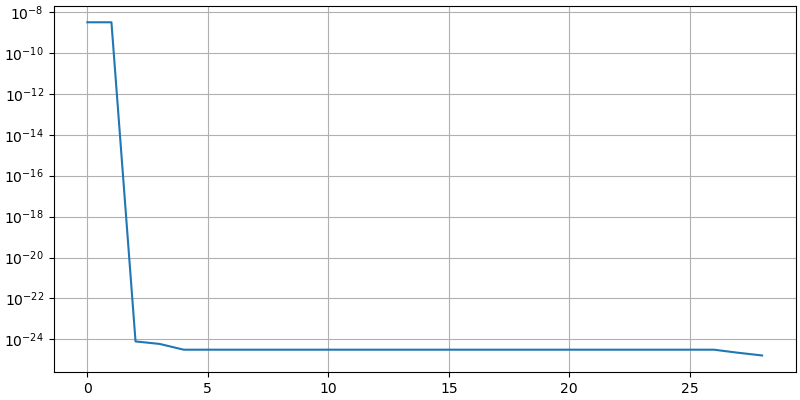

Decomp shapes (29, 29) (29,) (29, 200)
Trunc shapes (29, 10) (10,) (10, 200) 10
System eigenvalues [-8.87049007e+19 -9.42492610e+19 -1.10881702e+20 -1.38607098e+20
 -1.77417254e+20 -2.27352652e+20 -2.88366092e+20 -3.55317076e+20
 -3.55317094e+20 -3.57498863e+20 -3.57498866e+20 -3.60622681e+20
 -3.87832232e+20 -3.87832404e+20 -4.44036878e+20 -5.38845626e+20
 -6.45524275e+20 -7.63068071e+20 -8.96408840e+20 -1.03395117e+21
 -1.15172410e+21 -1.35352045e+21 -1.86756695e+21 -1.94527365e+21
 -2.01735606e+21 -3.23054432e+21 -8.26060830e+21 -8.46863768e+21
 -8.68508625e+21]
System eigenvalues [-1.01814607e+20 -1.13396737e+20 -1.77603406e+20 -2.27993679e+20
 -2.44023531e+20 -4.11854929e+20 -5.29155445e+20 -8.91525558e+20
 -1.13558380e+21 -5.94075539e+21]


C:\Users\Soske\AppData\Local\Temp\ipykernel_40808\3890475683.py:329: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplot_mosaic([[1, 2], [3, 4]], layout='constrained', figsize=(10,8))


[1.60660661e+09 1.69369369e+09 2.12012012e+09 2.48648649e+09
 3.23123123e+09 3.66066066e+09]
[1.49849850e+09 1.54654655e+09 1.67567568e+09 1.87387387e+09
 2.12012012e+09 2.39939940e+09 2.70270270e+09 3.02102102e+09
 3.35435435e+09 3.69369369e+09]


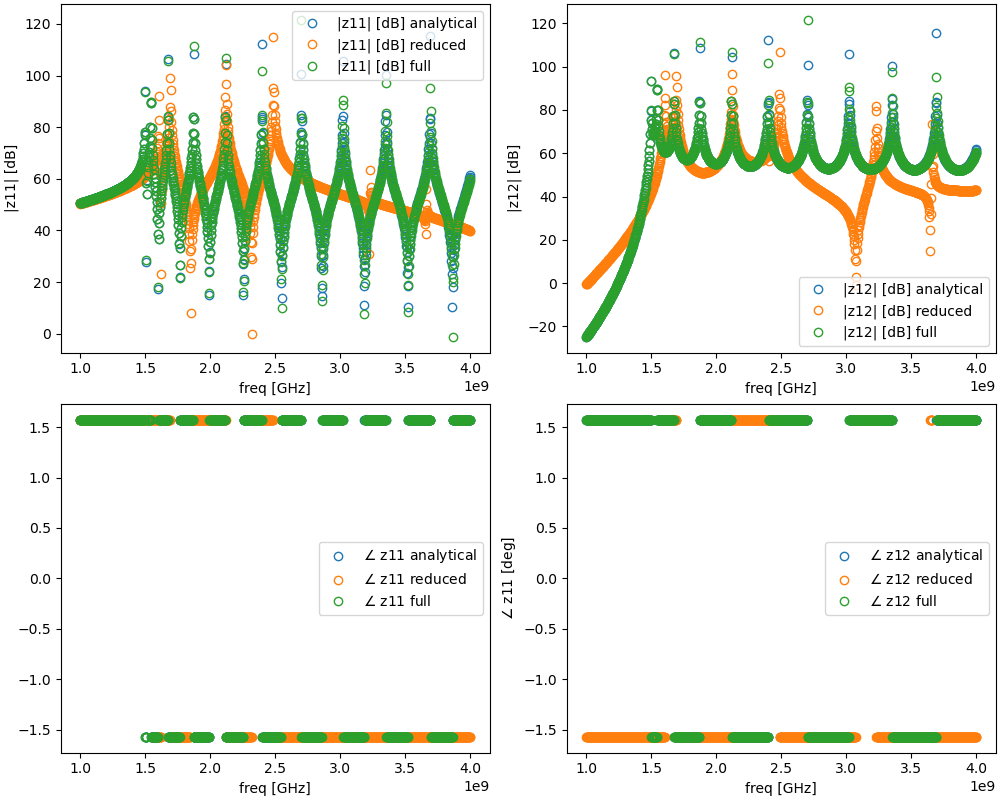

In [14]:
from copy import copy
import scipy.linalg as sl
from netgen.occ import *
import numpy as np


class Concat:
    def __init__(self, structs):
        self.structs = structs
        self.assign_global_port()
        self.geo = None
        self.mesh = None
        self.Wfull = None
        self.Zc, self.Zrd = [], []

    def glue_geo(self):
        offset = 0
        geo_list = []
        for struct in self.structs:
            if offset == 0:
                geo_list.append(struct.geo.geo)
            else:
                geo = struct.geo.geo.Move((0, 0, offset))
                geo_list.append(geo)
            offset += struct.geo.L

        self.geo = Glue(geo_list)
        self.mesh = Mesh(OCCGeometry(self.geo).GenerateMesh(maxh=0.05))
        Draw(self.mesh)

    def concat(self, connections):
        """
        Build permutation matrix that moves internal ports first.
        connections = [ ((sA, "portX"), (sB, "portY")), ... ]
        """
        # ---- 1. Total number of global ports ----
        self.nconnections = len(connections)
        total_ports = sum(len(s.ports) for s in self.structs)

        # ---- 2. Collect internal global indices ----
        internal = set()

        for (sA, pA), (sB, pB) in connections:
            gA = sA.global_offset + sA.port_indices[pA]
            gB = sB.global_offset + sB.port_indices[pB]
            internal.add(gA)
            internal.add(gB)

        internal = sorted(internal)

        # ---- 3. External ports = rest ----
        all_ports = set(range(total_ports))
        external = sorted(all_ports - set(internal))

        # ---- 4. Final permutation list ----
        # Internal ports first, then external
        self.nint, self.next = len(internal), len(external)
        perm = internal + external
        self.permutation = perm

        # ---- 5. Create full permutation matrix ----
        PT = np.zeros((total_ports, total_ports), dtype=int)
        for new_pos, old_pos in enumerate(perm):
            PT[new_pos, old_pos] = 1

        self.PT = PT
        self.P = PT.T
        return self.P

    def assign_global_port(self):
        global_ports = []
        offset = 0
        for struct in self.structs:
            struct.global_offset = offset
            offset += len(struct.ports)

    def build_global_excitation(self):
        """
        Assemble global excitation matrix I_global.
        Each struct provides struct.I with shape (n_ports, n_cols)
        or (n_ports,) for a single-column excitation.

        The result is:
            I_global = [ I_s1
                         I_s2
                         ...
                       ]
        No permutation is ever applied here.
        """
        # --- collect local blocks as 2D numpy arrays ---
        blocks = []
        for struct in self.structs:
            I_local = np.asarray(struct.I)

            # treat 1D as column vector
            if I_local.ndim == 1:
                I_local = I_local.reshape((-1, 1))

            # ensure correct number of rows
            n_ports = len(struct.ports)
            if I_local.shape[0] != n_ports:
                raise ValueError(
                    f"struct.I for {struct} has shape {I_local.shape}, "
                    f"expected ({n_ports}, _)"
                )

            blocks.append(I_local)

        # --- pad each block to the same number of columns ---
        max_cols = max(block.shape[1] for block in blocks)
        blocks_padded = []
        for B in blocks:
            if B.shape[1] < max_cols:
                pad = np.zeros((B.shape[0], max_cols - B.shape[1]), dtype=B.dtype)
                B = np.hstack([B, pad])
            blocks_padded.append(B)

        # --- vertical stack, NO permutation ---
        I_global = np.vstack(blocks_padded)

        self.I_global = I_global
        return I_global

    # def build_F(self):
    #     diag = []
    #     for _ in range(self.nconnections):
    #         diag.extend([1, -1])
    #     return np.diag(diag)

    def build_F(self, dtype=float):
        """
        Create the incidence-style matrix F for n_connections.
        For each connection, place the vector [1, -1] as a column block.

        Shape: (2*n_connections, n_connections)
        """
        F = np.zeros((2 * self.nconnections, self.nconnections), dtype=dtype)
        for j in range(self.nconnections):
            F[2*j : 2*j+2, j] = [1, -1]
        return F

    def build_matrices(self):
        # concatenation
        sArds, sBrds, sxtest = [], [], []
        for s in self.structs:
            sArds.append(s.Ard)
            sBrds.append(s.Brd)
            # print('sBrd',s.Brd.shape, s.Brd)
            sxtest.append(s.x_)

        Ab = sl.block_diag(sArds[0], sArds[1])
        Bb = sl.block_diag(sBrds[0], sBrds[1])
        print('Ab, Bb', Ab.shape, Bb.shape)
        xtest = np.vstack([sxtest[0], sxtest[1]])

        P = self.concat(connections)
        self.P = np.array([[0, 0, 1, 0],
                     [1, 0, 0, 0],
                      [0, 1, 0, 0],
                      [0, 0, 0, 1]])

        Ib = self.build_global_excitation()
        self.Ib = np.array([[1, 0],
                       [0, 1],
                       [1, 0],
                       [0, 1]])
        Isrt = self.P.T@self.Ib
        # printf('\nIsrt\n', Isrt)

        BbP = Bb@self.P
        Bb1 = BbP[:, 0:self.nint]
        # print('\nBb1\n', Bb1)
        Bb2 = BbP[:, self.nint:]
        self.Iint = Isrt[0:self.nint, :]
        self.Iext = Isrt[self.nint:, :]
        self.F = concat.build_F()
        F = concat.build_F()

        # CHECK KIRCHOFF, should be zero
        print('as', F.T.shape, Bb1.shape, xtest.shape)
        zero = F.T@Bb1.T@xtest
        self.Bb1 = Bb1
        self.xtest = xtest
        print('check F.T@Bb1.T@xb: ', zero)

        Bb1F = Bb1@F
        # print('\nBb1F\n', Bb1F)
        K = np.eye(Bb1F.shape[0]) - Bb1F@np.linalg.inv(Bb1F.T@Bb1F)@Bb1F.T
        print('check K idempotency: ', np.max(K - K.T@K))

        M = sl.null_space(Bb1F.T)
        KM = K@M
        print(KM.T.shape, Ab.shape, KM.shape)
        self.Ac = KM.T@Ab@KM
        self.Bc = KM.T@Bb2

        # check eigenvalues
        # self.check_eigs_reduced_system()

    # check eigenvalues
    def check_eigs_system(self, A, mode=None):
        lrp, xrp = sl.eigh(-A)
        # sort eigenmode and eigenvalues
        idx_sort = np.argsort(np.abs(lrp))
        lrp = lrp[idx_sort]
        xrp = xrp[:, idx_sort]
        # print('Matrix size ', A.shape)
        print("System eigenvalues", lrp)

    def solve_FD(self, fmin, fmax, nsamples=1000):
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.freqZrd = {'freqs': freqs}

        for kk, freq in enumerate(freqs):
            w = 2 * pi * freq
            lhs = -self.Ac - (w / c0) ** 2 * np.eye(self.Ac.shape[0])
            # get excitation matrices
            rhs = w / c0 * Z0 * self.Bc @ self.Iext # pay attention to the 1j removed from here always, fes is a real space

            x_ = np.linalg.solve(lhs, rhs)
            # self.x_ = np.linalg.solve(lhs, rhs) # TEMPORARY FOR TESTING

            if self.Wfull is None:
                self.Wfull = x_
            else:
                self.Wfull = np.hstack([self.Wfull, x_])

        return self.Wfull

    def zreduced(self, fmin, fmax, nsamples=1000):
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.freqZrd = {'freqs': freqs}
        for kk, freq in enumerate(freqs):
            w = 2 * pi * freq
            lhs = self.Ard - w**2 * np.eye(self.Ard.shape[0])
            # get excitation matrices
            rhs = w * self.Brd @ self.Iext # pay attention to the 1j removed from here always, fes is a real space

            x_ = np.linalg.solve(lhs, rhs)
            self.x_ = np.linalg.solve(lhs, rhs) # TEMPORARY FOR TESTING
            # xfull = self.Wr @ x_
            # if kk == -1:
            #     fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
            #     Ef = GridFunction(fes)
            #     Ef.vec.data = xfull[:, 0].ravel() # GridFunction vec.data takes a 1d array, must ravel
            #     Ef = BoundaryFromVolumeCF(Ef*1j)
            #     Draw(Norm(Ef), rwg.mesh, settings=settings)

            z = 1j*self.Brd.T @ x_ # pay attention to the 1j always
            self.Zrd.append(z)

        self.Zrd = np.array(self.Zrd)
        self.freqZrd['Z'] = self.Zrd
        return self.Zrd

    def zfull(self, fmin, fmax, nsamples=1000):
        freqs = np.linspace(fmin, fmax, nsamples)*1e9
        self.freqZc = {'freqs': freqs}

        for kk, freq in enumerate(freqs):
            w = 2 * pi * freq
            lhs = self.Ac - w** 2 * np.eye(self.Ac.shape[0])
            # get excitation matrices
            rhs = w * self.Bc @ self.Iext # pay attention to the 1j removed from here always, fes is a real space

            x_ = np.linalg.solve(lhs, rhs)

            # xfull = self.Wr @ x_
            # if kk == -1:
            #     fes = HCurl(self.mesh, order=self.fesorder, dirichlet=self.bc)
            #     Ef = GridFunction(fes)
            #     Ef.vec.data = xfull[:, 0].ravel() # GridFunction vec.data takes a 1d array, must ravel
            #     Ef = BoundaryFromVolumeCF(Ef*1j)
            #     Draw(Norm(Ef), rwg.mesh, settings=settings)

            z = 1j*self.Bc.T @ x_ # pay attention to the 1j always
            self.Zc.append(z)

        self.Zc = np.array(self.Zc)
        self.freqZc['Z'] = self.Zc
        return self.Zc

    def plotZ(self, which, ax=None):
        from scipy.signal import find_peaks
        # Z parameters
        if which == 'full':
            freqs = self.freqZc['freqs']
            Z11 = self.freqZc['Z'][:, 0, 0]
            Z21 = self.freqZc['Z'][:, 1, 0]
        elif which == 'reduced':
            freqs = self.freqZrd['freqs']
            Z11 = self.freqZrd['Z'][:, 0, 0]
            Z21 = self.freqZrd['Z'][:, 1, 0]
        else:
            freqs = self.freqZc['freqs']
            Z11 = self.freqZc['Z'][:, 0, 0]
            Z21 = self.freqZc['Z'][:, 1, 0]

        # plot z parameters
        if ax is None:
            fig, ax = plt.subplot_mosaic([[1, 2], [3, 4]], layout='constrained', figsize=(10,8))
        ax[1].plot(freqs, 20*np.log10(np.abs(Z11)), marker='o', label=f'|z11| [dB] {which}', mfc='none', lw=0)
        ax[2].plot(freqs, 20*np.log10(np.abs(Z21)), marker='o', label=f'|z12| [dB] {which}', mfc='none', lw=0)
        ax[1].set_ylabel('|z11| [dB]')
        ax[1].set_xlabel('freq [GHz]')
        ax[2].set_xlabel('freq [GHz]')
        ax[2].set_ylabel('|z12| [dB]')
        ax[1].legend()
        ax[2].legend()

        # plot phase
        ax[3].plot(freqs, np.angle(Z11), marker='o', label=fr'$\angle$ z11 {which}', mfc='none', lw=0)
        ax[4].plot(freqs, np.angle(Z21), marker='o', label=fr'$\angle$ z12 {which}', mfc='none', lw=0)
        ax[3].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[4].set_xlabel('freq [GHz]')
        ax[4].set_ylabel(r'$\angle$ z11 [deg]')
        ax[3].legend()
        ax[4].legend()

        peaks, _ = find_peaks(20*np.log10(np.abs(Z11)))
        print(freqs[peaks])
        # save Z parameters
        # import pickle
        # with open('Zparametes_coarse_mesh.pickle', 'wb') as handle:
        #     pickle.dump(Z, handle, protocol=pickle.HIGHEST_PROTOCOL)
        return ax

    def rom(self, tol=1e-19):
        U, S, Vt = np.linalg.svd(self.Wfull, full_matrices=False)
        fig,ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
        ax[1].plot(S)
        ax[1].set_yscale('log')
        plt.grid()
        plt.show()

        print('Decomp shapes', U.shape, S.shape, Vt.shape)
        # r = len(S[S>tol])
        r = len(S)
        r = 10
        Sr = S[:r]
        Vtr = Vt[:r, :]
        Wr = U[:, :r]
        print('Trunc shapes', Wr.shape, Sr.shape, Vtr.shape, r)

        # self._test_reconstruction(W, Wr, Sr, Vtr)
        Rr = Wr.T@self.Ac@Wr
        Rr = (Rr + Rr.T)/2
        # self._check_reduced_model(Wr, Rr, Mr)

        Ard = Rr
        Ard = (Ard + Ard.T)/2
        Brd = Wr.T @ self.Bc

        self.Wr, self.Ard, self.Brd = Wr, Ard, Brd
        return Wr, Ard, Brd

s1 = copy(struct)
s2 = copy(struct)
s3 = copy(struct)
print(s1.port_indices, s2.port_indices)
concat = Concat([s1, s2, s3])
# concat.glue_geo()
connections = [
    ((s1, "port2"), (s2, "port1")),
    # ((s2, "port2"), (s3, "port1"))
]
concat.build_matrices()
Xs = concat.solve_FD(1, 4, 100)
romres = concat.rom()
concat.check_eigs_system(concat.Ac)
concat.check_eigs_system(concat.Ard)

concat.zfull(1, 4, 1000)
concat.zreduced(1, 4, 1000)
ax = rwg_analytical.plot_analytical()
ax = concat.plotZ('reduced', ax)
ax = concat.plotZ('full', ax)


In [ ]:
concat.Bb1.T@concat.xtest
# Iunsrt = np.array([[1, 0], [0, 1], [1, 0], [0, 1]])
# concat.P.T@concat.Ib

In [3]:
import math
import itertools

def calculate_physical_eigenvalues(a_mm, b_mm, L_mm, num_eigenvalues=20):
    """
    Calculates and returns the first N physical eigenvalues (lambda = k^2)
    for a rectangular resonant cavity.

    Filters:
    - Excludes modes where (m, n) == (0, 0). These correspond to transverse
      indices that do not support any waveguide mode (TE or TM).
      This removes non-physical modes like (0, 0, 1).
    - Includes modes like (1, 0, 0) as requested, which correspond to the
      cutoff of the valid TE10 waveguide mode.

    Args:
        a_mm (float): Dimension a (width).
        b_mm (float): Dimension b (height).
        L_mm (float): Dimension L (length).
        num_eigenvalues (int): Number of eigenvalues to find.

    Returns:
        list: Sorted list of tuples (lambda, k, mode_string).
    """
    # Convert dimensions to meters
    a = a_mm / 1000.0
    b = b_mm / 1000.0
    L = L_mm / 1000.0

    # Pre-calculate squared constants
    pi_over_a_sq = (math.pi / a)**2
    pi_over_b_sq = (math.pi / b)**2
    pi_over_L_sq = (math.pi / L)**2

    max_index = 8  # Search space
    unique_eigenvalues = {}

    for m, n, p in itertools.product(range(max_index), repeat=3):

        # FILTER: Physical modes must be associated with a valid waveguide mode
        # in the transverse cross-section (a x b).
        # A waveguide mode exists only if indices (m, n) are not both zero.
        if m == 0 and n == 0:
            continue

        # Calculate eigenvalue
        lambda_val = (m**2 * pi_over_a_sq) + \
                     (n**2 * pi_over_b_sq) + \
                     (p**2 * pi_over_L_sq)

        if lambda_val not in unique_eigenvalues:
            unique_eigenvalues[lambda_val] = []
        unique_eigenvalues[lambda_val].append((m, n, p))

    # Sort by eigenvalue
    sorted_lambda_keys = sorted(unique_eigenvalues.keys())

    final_list = []
    for lambda_val in sorted_lambda_keys:
        k_val = math.sqrt(lambda_val)
        modes = unique_eigenvalues[lambda_val]

        # Format mode string
        mode_str = ", ".join(f"({m}, {n}, {p})" for m, n, p in sorted(modes))

        final_list.append((lambda_val, k_val, mode_str))

    return final_list[:num_eigenvalues]

# --- Main Execution ---
c0 = 299792458
A_DIMENSION_MM = 100
B_DIMENSION_MM = 50
L_DIMENSION_MM = 400
NUM_MODES_TO_FIND = 20

results = calculate_physical_eigenvalues(A_DIMENSION_MM, B_DIMENSION_MM, L_DIMENSION_MM, NUM_MODES_TO_FIND)

print(f"--- First {NUM_MODES_TO_FIND} Physical Eigenvalues for Rectangular Cavity ---")
print(f"Dims: a={A_DIMENSION_MM}mm, b={B_DIMENSION_MM}mm, L={L_DIMENSION_MM}mm")
print("-" * 100)
print(f"{'Rank':<5} | {'Lambda (k^2)':<20} | {'k (rad/m)':<20} | {'Mode Indices (m, n, p)'}")
print("-" * 100)

for i, (lam, k, m_str) in enumerate(results, 1):
    print(f"{i:<5} | {lam*c0**2:<.4e} | {k:<20.4f} | {m_str}")

print("-" * 100)


--- First 20 Physical Eigenvalues for Rectangular Cavity ---
Dims: a=100mm, b=50mm, L=400mm
----------------------------------------------------------------------------------------------------
Rank  | Lambda (k^2)         | k (rad/m)            | Mode Indices (m, n, p)
----------------------------------------------------------------------------------------------------
1     | 8.8704e+19 | 31.4159              | (1, 0, 0)
2     | 9.4248e+19 | 32.3828              | (1, 0, 1)
3     | 1.1088e+20 | 35.1241              | (1, 0, 2)
4     | 1.3860e+20 | 39.2699              | (1, 0, 3)
5     | 1.7741e+20 | 44.4288              | (1, 0, 4)
6     | 2.2730e+20 | 50.2900              | (1, 0, 5)
7     | 2.8829e+20 | 56.6359              | (1, 0, 6)
8     | 3.5481e+20 | 62.8319              | (0, 1, 0), (2, 0, 0)
9     | 3.6036e+20 | 63.3208              | (0, 1, 1), (1, 0, 7), (2, 0, 1)
10    | 3.7699e+20 | 64.7656              | (0, 1, 2), (2, 0, 2)
11    | 4.0471e+20 | 67.1044              | (

In [ ]:
# check if BTX = [u1 u2].T
dsd = 1
uu = 1j*B.T@np.array(Wfull).T[:, dsd]
print(uu)
Z11 = Z['1(1)1(1)']
Z21 = Z['1(1)2(1)']
print(Z11[dsd], Z21[dsd])
print(Z11)
print(uu/np.array([Z11[dsd], Z21[dsd]]))

In [ ]:
M2s = (M2 + M2.T)/2
R2s = (R2 + R2.T)/2

freedofs = fes.FreeDofs()
evals, evecs = sp.linalg.eigs(R2s[freedofs, :][:, freedofs], k=20, M=M2s[freedofs, :][:, freedofs], sigma=3000)
sort = np.argsort(evals)
evals_free = evals[sort]
evecs_free = evecs[:, sort]
mask = evals_free > 1
evals_free = evals_free[mask]
evecs_free = evecs_free[:, mask]
print(evals_free)


In [ ]:
freq_fes = []
for i, lam in enumerate(evals_free):
    freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
print(freq_fes)

In [ ]:
# reconstruct full
freedofs_indices = np.where(fes.FreeDofs())[0]
evecs_full = np.zeros((M2s.shape[0], evecs_free.shape[1]) )
evecs_full[freedofs_indices, :] = evecs_free
print(evecs_full.shape)

In [ ]:
E = GridFunction(fes)
xfull = evecs_full[:, 0]
E.vec.data = BaseVector(xfull)
E = BoundaryFromVolumeCF(E)
Draw(Norm(E), rwg.mesh, settings=settings)

In [ ]:
# evals = np.sort(evals)
# evals = evals[evals > 1]
# freq_fes = []
# for i, lam in enumerate(evals):
#     freq_fes.append(c0 * np.sqrt(lam) / (2 * np.pi) * 1e-6)
# print(np.array(freq_fes))
# # [1.49849850e+09 1.67567568e+09 2.12012012e+09 2.70570571e+09 3.37537538e+09 3.45945946e+09 3.70270270e+09 3.70870871e+09]

In [ ]:
# from scipy.signal import find_peaks
#
#
# # Z parameters
# Z11 = Z['1(1)1(1)']
# Z21 = Z['1(1)2(1)']
# print(Z11, '\n', Z11_a)
# print()
# print(Z21, '\n', Z21_a)
#
# # plot z parameters
# fig, ax = plt.subplot_mosaic([[1, 2]], layout='constrained', figsize=(10,4))
# ax[1].plot(freqs, 20*np.log10(np.abs(Z11)), marker='o', label='|z11| [dB] numerical')
# ax[1].plot(freqs, 20*np.log10(np.abs(Z11_a)), marker='v', label='|z11| [dB] analytic')
# ax[2].plot(freqs, 20*np.log10(np.abs(Z21)), marker='o', label='|z12| [dB] numerical')
# ax[2].plot(freqs, 20*np.log10(np.abs(Z21_a)), marker='v', label='|z12| [dB] analytic')
# ax[1].set_ylabel('|z11| [dB]')
# ax[1].set_xlabel('freq [GHz]')
# ax[2].set_xlabel('freq [GHz]')
# ax[2].set_ylabel('|z12| [dB]')
# ax[1].legend()
# ax[2].legend()
#
# # plot phase
# fig, ax = plt.subplot_mosaic([[1, 2]], layout='constrained', figsize=(10,4))
# ax[1].plot(freqs, np.angle(Z11), marker='o', label=r'$\angle$ z11 numerical')
# ax[1].plot(freqs, np.angle(Z11_a), marker='v', label=r'$\angle$ z11 analytic')
# ax[2].plot(freqs, np.angle(Z21), marker='o', label=r'$\angle$ z12 numerical')
# ax[2].plot(freqs, np.angle(Z21_a), marker='v', label=r'$\angle$ z12 analytic')
# ax[1].set_xlabel('freq [GHz]')
# ax[1].set_ylabel(r'$\angle$ z11 [deg]')
# ax[2].set_xlabel('freq [GHz]')
# ax[2].set_ylabel(r'$\angle$ z11 [deg]')
# ax[1].legend()
# ax[2].legend()
#
# peaks, _ = find_peaks(20*np.log10(np.abs(Z11)))
# print(freqs[peaks])
# # save Z parameters
# # import pickle
# # with open('Zparametes_coarse_mesh.pickle', 'wb') as handle:
# #     pickle.dump(Z, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# def z2s(Z, Z0):
#     I = np.eye(Z.shape[0])
#     D = np.sqrt(Z0) * I
#     Dinv = 1/np.sqrt(Z0) * I
#     A = Dinv@Z@Dinv
#     S = np.linalg.inv(A + I)@(A - I)
#     return S
#
# # ind = 900
# # Zmat = np.array([[Z11_a[ind], Z21_a[ind]], [Z21_a[ind], Z11_a[ind]]])
# # S = z2s(Zmat, ZTEs[ind])
# # print(S)
#
# S11 = []
# for ind in range(0, len(freqs)):
#     Zmat = np.array([[Z11[ind], Z21[ind]], [Z21[ind], Z11[ind]]])
#     # print(Zmat)
#     S = z2s(Zmat, ZTEs[ind])
#     S11.append(S[0, 1])
#
# S11a = []
# # allocate space
# for ind in range(0, len(freqs)):
#     Zmat = np.array([[Z11_a[ind], Z21_a[ind]], [Z21_a[ind], Z11_a[ind]]])
#     # print(Zmat)
#     S = z2s(Zmat, ZTEs[ind])
#     S11a.append(S[0, 1])
#
# fig, ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
# ax[1].plot(freqs, 20*np.log10(np.abs(S11)), marker='o', label='|S21| [dB] numerical')
# ax[1].plot(freqs, 20*np.log10(np.abs(S11a)), marker='v', label='|S21| [dB] analytic')
# plt.legend()

# fig, ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
# ax[1].plot(freqs, np.angle(S11), marker='o', label='|S21| [dB] numerical')
# ax[1].plot(freqs, np.angle(S11a), marker='v', label='|S21| [dB] analytic')
# plt.legend()

In [ ]:
from scipy.linalg import solve_triangular
# import scipy.linalg as sl
#
# def calculate_mac(v1, v2):
#     """
#     Calculates the Modal Assurance Criterion (MAC) between two vectors.
#     """
#     # Ensure vectors are column vectors (d x 1) for dot product
#     v1 = np.asarray(v1).flatten()
#     v2 = np.asarray(v2).flatten()
#
#     # Calculate the numerator: (v1.T @ v2)^2
#     numerator = np.dot(v1, v2)**2
#
#     # Calculate the denominator: (v1.T @ v1) * (v2.T @ v2)
#     denominator = np.dot(v1, v1) * np.dot(v2, v2)
#
#     # Handle division by zero (shouldn't happen with non-zero vectors)
#     if denominator == 0:
#         return 0.0
#
#     return numerator / denominator
#
# def check_reduced_model(Wr, Rr, Mr):
#     print('============Checking reduced system eigenvalue============')
#     # check eigenvalue sof reduced system
#     evals_r, evecs_r = sl.eigh(Rr, Mr)
#     # evals_r, evecs_r = sp.linalg.eigs(Rr, k=10, M=Mr)
#
#     sort = np.argsort(evals_r)
#     evals_r = evals_r[sort]
#     evecs_r = evecs_r[sort]
#     print('evals_rd', evals_r)
#
#     mode = 0
#     xr = Wr@evecs_r
#     xrm = xr[:, mode]
#
#     Er = GridFunction(fes)
#     Er.vec.data = BaseVector(xrm)
#     Er = BoundaryFromVolumeCF(Er)
#     Draw(Norm(Er), rwg.mesh, settings=settings)
#     print('============Done hecking reduced system eigenvalue============\n')
#     return xr
#
# def test_reconstruction(W, Wr, Sr, Vtr):
#     # test reconstruction
#     print('============Testing snap reconstruciton============')
#     Esnap = W
#     Erecon = Wr@np.diag(Sr)@Vtr
#     err = np.linalg.norm(Erecon - Esnap) / np.linalg.norm(Esnap)
#     print("Snap reconstruction error", err)
#     print('============Done testing snap reconstruciton============\n')
#
# def MOR(W, M2, R2, tol=20):
#
#     U, S, Vt = np.linalg.svd(W, full_matrices=False)
#     # fig,ax = plt.subplot_mosaic([[1]], layout='constrained', figsize=(8,4))
#     # ax[1].plot(S)
#     # ax[1].set_yscale('log')
#     # plt.grid()
#     # plt.show()
#
#     print('Decomp shapes', U.shape, S.shape, Vt.shape)
#     r = 10
#     Sr = S[:r]
#     Vtr = Vt[:r, :]
#     Wr = U[:, :r]
#     print('Trunc shapes', Wr.shape, Sr.shape, Vtr.shape, r)
#
#     test_reconstruction(W, Wr, Sr, Vtr)
#     Mr, Rr = Wr.T@M2@Wr, Wr.T@R2@Wr
#     Mr = (Mr + Mr.T)/2
#     Rr = (Rr + Rr.T)/2
#     xr = check_reduced_model(Wr, Rr, Mr)
#
#     lam, Q = sl.eigh(Mr)
#
#     inv_sqrt_lam = 1/np.sqrt(lam)
#     QTLinv = Q@np.diag(inv_sqrt_lam)
#
#     A = -QTLinv.T@Rr@QTLinv
#     A = (A + A.T)/2
#
#     return Wr, A, QTLinv, xr
#
# Wfull_copy = struct.Wfull.copy()
# Wr, Ard, QTLinv, xr = MOR(Wfull_copy, struct.M, struct.K)
#
# # for mode in range(10):
# #     x_proj = xr[:, mode]
# #     xfull = evecs_full[:, mode]
# #     mac_value = calculate_mac(xfull, x_proj)
# #     print(f"MAC value for mode {mode}: {mac_value:.6f}")#

In [ ]:
lrp, xrp = sl.eigh(-Ard)
# sort eigenmode and eigenvalues
idx_sort = np.argsort(np.abs(lrp))
lrp = lrp[idx_sort]
xrp = xrp[:, idx_sort]
print(lrp)

In [ ]:
Erd = GridFunction(fes)
x = Wr@QTLinv@xrp[:, 0]
Erd.vec.data = x
Erd = BoundaryFromVolumeCF(Erd)
Draw(Norm(Erd), rwg.mesh, settings=settings)

In [ ]:
# Bgfu = GridFunction(fes)
# Bgfu.vec.data = B[:, 0]
# Draw(Bgfu, rwg.mesh, settings=settings)

# Wr, QTLinv, Ard are correct, I is correct, is B correct? I get theimpedance parameters correct to a factor but the fields are not correct
Brd = QTLinv.T@Wr.T@B
I = np.array([[1, 0],[0, 1]])

z11, z12 = [], []
for kk, freq in enumerate(freqs):
    freq = float(freq)
    w = 2*pi*freq

    lhs = -Ard-(w/c0)**2*np.eye(Ard.shape[0])
    rhs = 1j*w/c0*Z0*Brd@I

    x_ = np.linalg.solve(lhs, rhs)
    # print(Wr.shape, QTLinv.shape, Brd.shape, B.shape, x_.shape)
    xfull = Wr@QTLinv@x_
    if kk == 1:
        Ef = GridFunction(fes)
        Ef.vec.data = xfull[:, 0]
        Ef = BoundaryFromVolumeCF(Ef)
        Draw(Norm(Ef), rwg.mesh, settings=settings)

    z = Brd.T@x_
    z11.append(z[0, 0])
    z12.append(z[0, 1])

# print(z11)

In [ ]:
import scipy.linalg as sl
import numpy as np

import numpy as np

def permutation_matrix(blocks):
    """
    blocks: list of lists of local indices, e.g. [[1,2,3],[2,1,3],[1,2]]
    Returns:
        chain: flattened array with accumulated shifts
        perm: permutation vector (internal indices first, then external)
        P: permutation matrix
    """
    # Step 1: build the chain
    chain = []
    offset = 0
    for blk in blocks:
        chain.extend([i + offset for i in blk])
        offset += len(blk)  # shift by accumulated lengths

    chain = np.array(chain)

    # Step 2: identify internal and external indices
    internal = []
    for i, blk in enumerate(blocks):
        if i != 0 and i != len(blocks) - 1:  # skip first and last blocks
            start = sum(len(blocks[j]) for j in range(i))
            end = start + len(blk)
            # first and last of this block are internal
            internal.append(start)
            internal.append(end-1)
    internal = np.array(internal)

    # external = all indices not in internal
    all_idx = np.arange(len(chain))
    external = np.array([i for i in all_idx if i not in internal])

    # permutation vector: internal first, then external
    perm = np.concatenate([internal, external])

    # Step 3: build permutation matrix
    n = len(chain)
    P = np.zeros((n,n), dtype=int)
    for new_idx, old_idx in enumerate(perm):
        P[new_idx, old_idx] = 1

    return chain, perm, P


# concatenation
Ab = sl.block_diag(Ard, Ard)
Bb = sl.block_diag(Brd, Brd)
ib = np.vstack([I, I])
print(Ab.shape, Bb.shape, ib.shape)

# build permutation matrix
concat = [['port1', 'port2'], ['port1', 'port3', 'port2', ], ['port1', 'port2']]
flat = [x for row in concat for x in row]
mapping = {name: i+1 for i, name in enumerate(dict.fromkeys(flat))}
concat_array = [[mapping[x] for x in row] for row in concat]
print(concat_array)
chain, perm, P = permutation_matrix(concat_array)
print(chain, perm, P)
print(rwg.mesh.GetBoundaries())

In [ ]:
def excitation_matrix_from_ports(boundaries):
    # Get ports in order of appearance
    ports = [b for b in boundaries if "port" in b]
    n_ports = len(ports)

    # Identity matrix for excitation
    I = np.eye(n_ports, dtype=int)

    # Map port names to row indices
    port_indices = {port: i for i, port in enumerate(ports)}

    return I, ports, port_indices
faces_order = ['bottom', 'right', 'top', 'left', 'port2', 'port1']
I, ports, port_indices = excitation_matrix_from_ports(faces_order)

print("Ports:", ports)       # ['port2', 'port1']
print("Excitation matrix:\n", I)


In [ ]:
from scipy.signal import find_peaks

# Z parameters
Z11 = z11
Z21 = z12
# print(np.array(Z11)/Z11_a)
# print(np.array(Z21)/Z21_a)
# plot z parameters
fig, ax = plt.subplot_mosaic([[1, 2]], layout='constrained', figsize=(10,4))
ax[1].plot(freqs, 20*np.log10(np.abs(Z11)), marker='o', label='|z11| [dB] numerical')
ax[1].plot(freqs, 20*np.log10(np.abs(Z11_a)), marker='v', label='|z11| [dB] analytic')
ax[2].plot(freqs, 20*np.log10(np.abs(Z21)), marker='o', label='|z12| [dB] numerical')
ax[2].plot(freqs, 20*np.log10(np.abs(Z21_a)), marker='v', label='|z12| [dB] analytic')
ax[1].set_ylabel('|z11| [dB]')
ax[1].set_xlabel('freq [GHz]')
ax[2].set_xlabel('freq [GHz]')
ax[2].set_ylabel('|z12| [dB]')
ax[1].legend()
ax[2].legend()

# plot phase
fig, ax = plt.subplot_mosaic([[1, 2]], layout='constrained', figsize=(10,4))
ax[1].plot(freqs, np.angle(Z11), marker='o', label=r'$\angle$ z11 numerical')
ax[1].plot(freqs, np.angle(Z11_a), marker='v', label=r'$\angle$ z11 analytic')
ax[2].plot(freqs, np.angle(Z21), marker='o', label=r'$\angle$ z12 numerical')
ax[2].plot(freqs, np.angle(Z21_a), marker='v', label=r'$\angle$ z12 analytic')
ax[1].set_xlabel('freq [GHz]')
ax[1].set_ylabel(r'$\angle$ z11 [deg]')
ax[2].set_xlabel('freq [GHz]')
ax[2].set_ylabel(r'$\angle$ z11 [deg]')
ax[1].legend()
ax[2].legend()

# peaks, _ = find_peaks(20*np.log10(np.abs(Z11)))
# print(freqs[peaks])
# save Z parameters
# import pickle
# with open('Zparametes_coarse_mesh.pickle', 'wb') as handle:
#     pickle.dump(Z, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# vtk = VTKOutput(
#     ma=mesh,
#     coefs=[Esol.real],             # List of GridFunctions or CoefficientFunctions to export
#     names=["solution"],      # List of names for the fields in the VTK file
#     filename="my_ngsolve_output", # Base name for the exported files
#     subdivision=2            # Optional: Refinement level for higher order elements
# )
# # Export the GridFunction to VTK files
# vtk.Do()

In [ ]:
# PSEUDO-NGSOLVE CODE (illustrative)
from ngsolve import *
from netgen.geom2d import unit_square  # replace with your geometry

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

L, b = 1000e-3, 100e-3
a = 2*b
rwg = Rectangle(a, b).Face().Extrude(L*Z)
rwg.faces.Max(Z).name = "port1"
rwg.faces.Min(Z).name = "port2"
rwg.faces.Min(Y).name = "bottom"
rwg.faces.Max(Y).name = "top"
rwg.faces.Min(X).name = "left"
rwg.faces.Max(X).name = "right"
rwg.faces.Min(Z).col = (1, 0, 0)
rwg.faces.Max(Z).col = (1, 0, 0)

rwg.mat('vacuum')

mesh = Mesh(OCCGeometry(rwg).GenerateMesh(maxh=0.05))
mesh.Curve(3)

order = 3
fes = HCurl(mesh, order=order, dirichlet="pec")
fesH = HCurl(mesh, order=order)   # H in same type, or use different space

# coefficient functions (scalars)
eps = CoefficientFunction(1.0)    # replace with your epsilon
mu  = CoefficientFunction(1.0)    # replace with your mu

# bilinear forms (mass and curl operators)
M_e = BilinearForm(fes)
M_e += eps * InnerProduct(u, v) * dx
M_e.Assemble()
M_e_mat = M_e.mat

M_h = BilinearForm(fesH)
M_h += mu * InnerProduct(u, v) * dx
M_h.Assemble()
M_h_mat = M_h.mat

C = BilinearForm(fes, fesH)  # discrete curl operator assembly depends on NGsolve version
C += InnerProduct(curl(u), v) * dx
C.Assemble()
C_mat = C.mat

# GridFunctions
E = GridFunction(fes)
H = GridFunction(fesH)

# Beam parameters
q = 1.0
v_beam = (0.0, 0.0, 1.0)  # beam velocity vector
sigma = 0.01

def beam_J(x, t):
    # x is a tuple; 3D example -- replace dimension accordingly
    xc = (x[0]-x0 - v_beam[0]*t, x[1]-y0 - v_beam[1]*t, x[2]-z0 - v_beam[2]*t)
    r2 = xc[0]**2 + xc[1]**2 + xc[2]**2
    pref = q / ((2*pi)**1.5 * sigma**3)
    return [pref * v_beam[i] * exp(-r2/(2*sigma**2)) for i in range(3)]

# Time stepping parameters
dt = 1e-3
t = 0.0
Tfinal = 1.0

# Preconditioners / solvers for mass solves
solverE = CGSolver(M_e_mat, precond=Preconditioner(M_e_mat))  # illustrative
solverH = CGSolver(M_h_mat, precond=Preconditioner(M_h_mat))

# Leap-frog loop (staggered)
while t < Tfinal:
    # compute J at t+dt/2 and project to fes
    Jfunc = CoefficientFunction(lambda x: beam_J(x, t+dt/2))
    Jgf = GridFunction(fes)
    Jgf.Set(Jfunc)   # project current vector into FE space

    # update H^{n+1/2}  :  M_h * (Hnew - Hold)/dt = - C^T * E
    rhsH = -C_mat.T * E.vec
    rhsH *= dt
    rhsH += M_h_mat * H.vec   # RHS for linear solve
    H.vec.data = solverH * rhsH

    # update E^{n+1} : M_e * (Enew - E)/dt = C * Hnew - J^{n+1/2}
    rhsE = C_mat * H.vec - Jgf.vec
    rhsE *= dt
    rhsE += M_e_mat * E.vec
    E.vec.data = solverE * rhsE

    t += dt


# Hex mesh

In [ ]:
# Eigenmode
import gmsh
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve import Mesh, HCurl, H1, specialcf
from ngsolve import BilinearForm, SymbolicBFI, grad, curl
from ngsolve.la import EigenValues_Preconditioner
import scipy.sparse as sp

settings = {'Objects': {'Clipping Plane': True, 'Vectors': True}, 'Colormap': {'ncolors': 125},
            'Clipping': {'enable': True, 'x': 1, 'y': 0, 'z': 0},
           'Vectors': {'grid_size': 200}}

mu0 = 4 * pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

L, b = 500e-3, 100e-3
a = 2*b
rwg = Box((0, 0, 0), (a, b, L))
rwg.faces.Min(X).name = "PEC"
rwg.faces.Max(X).name = "PEC"
rwg.faces.Min(Y).name = "PEC"
rwg.faces.Max(Y).name = "PEC"
rwg.faces.Min(Z).name = "PMC"
rwg.faces.Max(Z).name = "PMC"

rwg.mat('vacuum')
rwg.faces.Min(Z).Identify(rwg.faces.Max(Z), "bot-top", type=IdentificationType.CLOSESURFACES)
# rwg.faces.Min(Y).Identify(rwg.faces.Max(Y), "bot-top", type=IdentificationType.CLOSESURFACES)
ngmesh = OCCGeometry(rwg).GenerateMesh(maxh=0.01, quad_dominated=True)

mesh = Mesh(ngmesh)
Draw(mesh);
mesh.Curve(3)
print(mesh.GetBoundaries(), mesh.GetMaterials())
# Draw(mesh)

# setup fes
order = 2
fes = HCurl(mesh, order=order, dirichlet="PEC")
u, v = fes.TnT()

a = BilinearForm(curl(u)*curl(v)*dx)
m = BilinearForm(u*v*dx)
apre = BilinearForm(curl(u)*curl(v)*dx + u*v*dx)
pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

with TaskManager():
    a.Assemble()
    m.Assemble()
    apre.Assemble()
    
    G, fesh1 = fes.CreateGradient()
    GT = G.CreateTranspose()
    math1 = GT @ m.mat @ G
#     math1[0, 0] += 1
    invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fesh1.FreeDofs())
    
    proj = IdentityMatrix() - G@invh1@GT@m.mat
    projpre = proj @ pre.mat

    evals, evecs = solvers.PINVIT(a.mat, m.mat, pre=projpre, num=10, maxit=20,
                                  printrates=False)

freq_fes = []
for i, lam in enumerate(evals):
    freq_fes.append(c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) * 1e-6)
print(freq_fes)

# plot results
# plot results
gfu_E = []
gfu_H = []
for i in range(len(evecs)):
    w = 2 * pi * freq_fes[i] * 1e6
    gfu = GridFunction(fes)
    gfu.vec.data = evecs[i]

    gfu_E.append(gfu)
    gfu_H.append(1j / (mu0 * w) * curl(gfu))
    
Draw(BoundaryFromVolumeCF(Norm(gfu_E[1])), mesh, order=4, settings=settings)
# Draw(gfu_E[1], mesh, settings=settings)